# IMC Prosperity Round 5 — Log Analysis & Strategy Notebook

This notebook updates the earlier round-3 analysis for the round-5 universe: 50 new products split into 10 baskets of 5 products each.

The goal is to identify the structures that persist across the sample days, quantify them cleanly, and turn them into a robust production view rather than a brittle hardcoded script.

## 0 — Configuration & Imports

In [3]:
from pathlib import Path
import warnings
import math
import statistics as stats

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

# Round 5 data directory: one level up from algorithm/, in data/
DATA_DIR = Path(__file__).parent.parent / "data" if "__file__" in dir() else Path("../data")

PRICE_FILES = [
    DATA_DIR / "prices_round_5_day_2.csv",
    DATA_DIR / "prices_round_5_day_3.csv",
    DATA_DIR / "prices_round_5_day_4.csv",
]

TRADE_FILES = [
    DATA_DIR / "trades_round_5_day_2.csv",
    DATA_DIR / "trades_round_5_day_3.csv",
    DATA_DIR / "trades_round_5_day_4.csv",
]

## 1 — Parse Log Files

The files are semicolon-separated CSVs.  
The price files contain the top-of-book snapshots; the trade files contain the executed tape.

In [4]:
def read_semicolon_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, sep=";")
    df.columns = [c.strip() for c in df.columns]
    return df


prices_raw = pd.concat([read_semicolon_csv(p) for p in PRICE_FILES], ignore_index=True)
trades_raw = pd.concat([read_semicolon_csv(p) for p in TRADE_FILES], ignore_index=True)

numeric_price_cols = [
    "day", "timestamp",
    "bid_price_1", "bid_volume_1", "bid_price_2", "bid_volume_2", "bid_price_3", "bid_volume_3",
    "ask_price_1", "ask_volume_1", "ask_price_2", "ask_volume_2", "ask_price_3", "ask_volume_3",
    "mid_price", "profit_and_loss",
]
for c in numeric_price_cols:
    if c in prices_raw.columns:
        prices_raw[c] = pd.to_numeric(prices_raw[c], errors="coerce")

numeric_trade_cols = ["timestamp", "price", "quantity"]
for c in numeric_trade_cols:
    if c in trades_raw.columns:
        trades_raw[c] = pd.to_numeric(trades_raw[c], errors="coerce")

prices_raw["spread"] = prices_raw["ask_price_1"] - prices_raw["bid_price_1"]
prices_raw["top_depth"] = prices_raw["bid_volume_1"].abs() + prices_raw["ask_volume_1"].abs()
prices_raw["book_imbalance"] = (
    prices_raw["bid_volume_1"].abs() - prices_raw["ask_volume_1"].abs()
) / prices_raw["top_depth"].replace(0, np.nan)

print("Prices:", prices_raw.shape)
print("Trades :", trades_raw.shape)
print("Unique products in prices:", prices_raw["product"].nunique())
print("Unique products in trades :", trades_raw["symbol"].nunique())
display(prices_raw.head())
display(trades_raw.head())

Prices: (1500000, 20)
Trades : (35385, 7)
Unique products in prices: 50
Unique products in trades : 50


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,spread,top_depth,book_imbalance
0,2,0,PEBBLES_L,9994,13,9992.0,21.0,NaN,NaN,10006,13,10008.0,21.0,NaN,NaN,10000.0,0.0,12,26,0.0
1,2,0,SNACKPACK_RASPBERRY,9992,36,9990.0,45.0,NaN,NaN,10008,36,10010.0,45.0,NaN,NaN,10000.0,0.0,16,72,0.0
2,2,0,UV_VISOR_RED,9994,22,9992.0,26.0,NaN,NaN,10006,22,10008.0,26.0,NaN,NaN,10000.0,0.0,12,44,0.0
3,2,0,PEBBLES_M,9994,13,9992.0,21.0,NaN,NaN,10006,13,10008.0,21.0,NaN,NaN,10000.0,0.0,12,26,0.0
4,2,0,GALAXY_SOUNDS_DARK_MATTER,9994,22,9992.0,26.0,NaN,NaN,10006,22,10008.0,26.0,NaN,NaN,10000.0,0.0,12,44,0.0


,timestamp,buyer,seller,symbol,currency,price,quantity
0,1700,NaN,NaN,GALAXY_SOUNDS_BLACK_HOLES,XIRECS,9969.0,4
1,1700,NaN,NaN,GALAXY_SOUNDS_DARK_MATTER,XIRECS,9977.0,4
2,1700,NaN,NaN,GALAXY_SOUNDS_PLANETARY_RINGS,XIRECS,9957.0,4
3,1700,NaN,NaN,GALAXY_SOUNDS_SOLAR_FLAMES,XIRECS,9976.0,4
4,1700,NaN,NaN,GALAXY_SOUNDS_SOLAR_WINDS,XIRECS,10084.0,4


## 1a — Round 5 product universe and basket map

The 50 products are organised into 10 baskets of 5 products.  
This section makes that mapping explicit and checks that the sample files contain the full set.

In [5]:
BASKETS = {
    "GALAXY_SOUNDS": [
        "GALAXY_SOUNDS_DARK_MATTER",
        "GALAXY_SOUNDS_BLACK_HOLES",
        "GALAXY_SOUNDS_PLANETARY_RINGS",
        "GALAXY_SOUNDS_SOLAR_WINDS",
        "GALAXY_SOUNDS_SOLAR_FLAMES",
    ],
    "SLEEP_POD": [
        "SLEEP_POD_SUEDE",
        "SLEEP_POD_LAMB_WOOL",
        "SLEEP_POD_POLYESTER",
        "SLEEP_POD_NYLON",
        "SLEEP_POD_COTTON",
    ],
    "MICROCHIP": [
        "MICROCHIP_CIRCLE",
        "MICROCHIP_OVAL",
        "MICROCHIP_SQUARE",
        "MICROCHIP_RECTANGLE",
        "MICROCHIP_TRIANGLE",
    ],
    "PEBBLES": [
        "PEBBLES_XS",
        "PEBBLES_S",
        "PEBBLES_M",
        "PEBBLES_L",
        "PEBBLES_XL",
    ],
    "ROBOT": [
        "ROBOT_VACUUMING",
        "ROBOT_MOPPING",
        "ROBOT_DISHES",
        "ROBOT_LAUNDRY",
        "ROBOT_IRONING",
    ],
    "UV_VISOR": [
        "UV_VISOR_YELLOW",
        "UV_VISOR_AMBER",
        "UV_VISOR_ORANGE",
        "UV_VISOR_RED",
        "UV_VISOR_MAGENTA",
    ],
    "TRANSLATOR": [
        "TRANSLATOR_SPACE_GRAY",
        "TRANSLATOR_ASTRO_BLACK",
        "TRANSLATOR_ECLIPSE_CHARCOAL",
        "TRANSLATOR_GRAPHITE_MIST",
        "TRANSLATOR_VOID_BLUE",
    ],
    "PANEL": [
        "PANEL_1X2",
        "PANEL_2X2",
        "PANEL_1X4",
        "PANEL_2X4",
        "PANEL_4X4",
    ],
    "OXYGEN_SHAKE": [
        "OXYGEN_SHAKE_MORNING_BREATH",
        "OXYGEN_SHAKE_EVENING_BREATH",
        "OXYGEN_SHAKE_MINT",
        "OXYGEN_SHAKE_CHOCOLATE",
        "OXYGEN_SHAKE_GARLIC",
    ],
    "SNACKPACK": [
        "SNACKPACK_CHOCOLATE",
        "SNACKPACK_VANILLA",
        "SNACKPACK_PISTACHIO",
        "SNACKPACK_STRAWBERRY",
        "SNACKPACK_RASPBERRY",
    ],
}

all_products = sorted({p for plist in BASKETS.values() for p in plist})
observed_products = set(prices_raw["product"].dropna().unique())
missing_from_files = sorted(set(all_products) - observed_products)
extra_in_files = sorted(observed_products - set(all_products))

universe_rows = []
for basket, plist in BASKETS.items():
    for p in plist:
        universe_rows.append({
            "basket": basket,
            "product": p,
            "in_files": p in observed_products,
        })

universe_df = pd.DataFrame(universe_rows)
display(
    universe_df.assign(in_files=lambda x: x["in_files"].map({True: "yes", False: "no"}))
               .groupby("basket", as_index=False)
               .agg(products=("product", "count"), present=("in_files", lambda s: (s == "yes").sum()))
)

print("Missing from files:", missing_from_files)
print("Unexpected extras  :", extra_in_files)

,basket,products,present
0,GALAXY_SOUNDS,5,5
1,MICROCHIP,5,5
2,OXYGEN_SHAKE,5,5
3,PANEL,5,5
4,PEBBLES,5,5
5,ROBOT,5,5
6,SLEEP_POD,5,5
7,SNACKPACK,5,5
8,TRANSLATOR,5,5
9,UV_VISOR,5,5


Missing from files: []
Unexpected extras  : []


## 2 — Build per-product market dataframes

Each product gets a consistent set of features:
mid, spread, top-of-book imbalance, short-horizon returns, and a basic microprice proxy.

In [6]:
def add_market_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy().sort_values(["day", "timestamp"]).reset_index(drop=True)

    out["mid_price"] = pd.to_numeric(out["mid_price"], errors="coerce")
    out["spread"] = out["ask_price_1"] - out["bid_price_1"]
    out["bid_depth_1"] = pd.to_numeric(out["bid_volume_1"], errors="coerce").abs()
    out["ask_depth_1"] = pd.to_numeric(out["ask_volume_1"], errors="coerce").abs()
    out["top_depth"] = out["bid_depth_1"] + out["ask_depth_1"]
    out["book_imbalance"] = (out["bid_depth_1"] - out["ask_depth_1"]) / out["top_depth"].replace(0, np.nan)
    out["microprice"] = (
        out["ask_price_1"] * out["bid_depth_1"] + out["bid_price_1"] * out["ask_depth_1"]
    ) / out["top_depth"].replace(0, np.nan)
    out["mid_ret_1"] = out["mid_price"].diff()
    out["mid_ret_5"] = out["mid_price"].diff(5)
    out["mid_log_ret_1"] = np.log(out["mid_price"]).diff()
    out["ema_10"] = out["mid_price"].ewm(span=10, adjust=False).mean()
    out["ema_40"] = out["mid_price"].ewm(span=40, adjust=False).mean()
    out["trend_10_40"] = out["ema_10"] - out["ema_40"]
    out["z_mid_50"] = (out["mid_price"] - out["mid_price"].rolling(50, min_periods=10).mean()) / out["mid_price"].rolling(50, min_periods=10).std()
    out["day_session"] = (out["timestamp"] // 1000).astype("Int64")
    return out


def autocorr(series: pd.Series, lag: int = 1) -> float:
    s = pd.to_numeric(series, errors="coerce").dropna()
    if len(s) <= lag:
        return np.nan
    return float(s.autocorr(lag))


mkt = {
    p: add_market_features(prices_raw.loc[prices_raw["product"] == p].copy())
    for p in all_products
}

master_prices = pd.concat([df.assign(product=p) for p, df in mkt.items()], ignore_index=True)

print("Built market frames for", len(mkt), "products.")
print("Rows in master price panel:", len(master_prices))
display(master_prices.head())

Built market frames for 50 products.
Rows in master price panel: 1500000


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,...,ask_depth_1,microprice,mid_ret_1,mid_ret_5,mid_log_ret_1,ema_10,ema_40,trend_10_40,z_mid_50,day_session
0,2,0,GALAXY_SOUNDS_BLACK_HOLES,9994,22,9992.0,26.0,NaN,NaN,10006,...,22,10000.0,NaN,NaN,NaN,10000.000000,10000.000000,0.000000,NaN,0
1,2,100,GALAXY_SOUNDS_BLACK_HOLES,10001,18,10000.0,25.0,NaN,NaN,10014,...,18,10007.5,7.5,NaN,0.00075,10001.363636,10000.365854,0.997783,NaN,0
2,2,200,GALAXY_SOUNDS_BLACK_HOLES,9996,19,9995.0,31.0,NaN,NaN,10009,...,19,10002.5,-5.0,NaN,-0.00050,10001.570248,10000.469958,1.100290,NaN,0
3,2,300,GALAXY_SOUNDS_BLACK_HOLES,9994,25,9993.0,33.0,NaN,NaN,10007,...,25,10000.5,-2.0,NaN,-0.00020,10001.375657,10000.471424,0.904234,NaN,0
4,2,400,GALAXY_SOUNDS_BLACK_HOLES,9999,14,9997.0,32.0,NaN,NaN,10012,...,14,10005.5,5.0,NaN,0.00050,10002.125538,10000.716720,1.408818,NaN,0


## 3 — Quick cross-section

This section gives the fastest global view:
- average price level,
- average spread,
- short-horizon volatility,
- short-horizon return autocorrelation,
- and rough inventory pressure.

In [6]:
global_summary = (
    master_prices.groupby("product")
    .agg(
        mean_mid=("mid_price", "mean"),
        std_mid=("mid_price", "std"),
        min_mid=("mid_price", "min"),
        max_mid=("mid_price", "max"),
        mean_spread=("spread", "mean"),
        median_spread=("spread", "median"),
        mean_depth=("top_depth", "mean"),
        mean_imbalance=("book_imbalance", "mean"),
        ret_vol=("mid_ret_1", "std"),
        ret_autocorr1=("mid_ret_1", lambda s: autocorr(s, 1)),
        price_autocorr1=("mid_price", lambda s: autocorr(s, 1)),
    )
    .reset_index()
)

global_summary["range_mid"] = global_summary["max_mid"] - global_summary["min_mid"]
display(global_summary.sort_values("mean_mid").reset_index(drop=True))

,product,mean_mid,std_mid,min_mid,max_mid,mean_spread,median_spread,mean_depth,mean_imbalance,ret_vol,ret_autocorr1,price_autocorr1,range_mid
0,PEBBLES_XS,7404.639767,1449.546839,5052.5,10496.0,9.744867,9.0,26.795333,0.000568,15.052188,-0.015544,0.999946,5443.5
1,UV_VISOR_AMBER,7911.696250,996.917584,6488.5,10035.5,10.320500,10.0,36.539600,-0.000300,8.004815,-0.004189,0.999968,3547.0
2,MICROCHIP_OVAL,8179.598717,1551.911621,5375.0,10433.0,7.449767,8.0,15.544067,0.002485,12.477798,-0.007204,0.999968,5058.0
3,ROBOT_IRONING,8701.570267,771.029728,7458.5,10102.0,6.392933,6.0,16.702933,-0.000082,10.443533,-0.125287,0.999908,2643.5
4,MICROCHIP_RECTANGLE,8732.439350,752.019290,7327.5,10442.5,7.885767,8.0,14.444267,-0.000633,13.130087,-0.002692,0.999848,3115.0
5,PANEL_1X2,8922.729017,589.916608,7667.0,10203.0,11.509767,12.0,36.512800,-0.000251,9.054059,-0.002367,0.999882,2536.0
6,PEBBLES_S,8932.356733,833.282141,6784.5,10687.0,11.551533,12.0,24.813633,0.000467,15.020455,0.007715,0.999838,3902.5
7,ROBOT_VACUUMING,9166.775783,535.258653,8242.5,10303.0,6.753300,7.0,17.145467,0.002987,9.235882,-0.007952,0.999851,2060.5
8,MICROCHIP_CIRCLE,9214.885283,532.512209,8303.5,10731.5,8.262167,8.0,13.522233,0.000813,9.234282,-0.004963,0.999850,2428.0
9,OXYGEN_SHAKE_EVENING_BREATH,9271.895000,399.821495,8277.5,10300.0,11.860467,12.0,36.512800,-0.000251,10.982947,-0.122689,0.999623,2022.5


## 4 — Basket overview table

This table is the first structural filter for round 5:
- tightly clustered baskets,
- spread-out baskets,
- liquid baskets,
- or baskets with more trend than reversion.

In [7]:
basket_overview_rows = []
for basket, plist in BASKETS.items():
    df = master_prices[master_prices["product"].isin(plist)].copy()
    pivot = df.pivot_table(index=["day", "timestamp"], columns="product", values="mid_price").sort_index()
    group_mid = pivot.mean(axis=1)
    residual = pivot.sub(group_mid, axis=0)

    for p in plist:
        p_df = mkt[p]
        res = residual[p].dropna()
        basket_overview_rows.append({
            "basket": basket,
            "product": p,
            "mean_mid": float(p_df["mid_price"].mean()),
            "mean_spread": float(p_df["spread"].mean()),
            "ret_vol": float(p_df["mid_ret_1"].std()),
            "ret_autocorr1": autocorr(p_df["mid_ret_1"], 1),
            "price_autocorr1": autocorr(p_df["mid_price"], 1),
            "residual_abs_mean": float(res.abs().mean()) if len(res) else np.nan,
            "residual_std": float(res.std()) if len(res) else np.nan,
            "residual_autocorr1": autocorr(res, 1) if len(res) > 2 else np.nan,
        })

basket_overview = pd.DataFrame(basket_overview_rows)
basket_rank = (
    basket_overview.groupby("basket")
    .agg(
        avg_mid=("mean_mid", "mean"),
        avg_spread=("mean_spread", "mean"),
        avg_ret_vol=("ret_vol", "mean"),
        avg_price_autocorr=("price_autocorr1", "mean"),
        avg_residual_abs=("residual_abs_mean", "mean"),
        avg_residual_std=("residual_std", "mean"),
        avg_residual_autocorr=("residual_autocorr1", "mean"),
    )
    .sort_values("avg_residual_abs")
    .reset_index()
)
display(basket_rank)

,basket,avg_mid,avg_spread,avg_ret_vol,avg_price_autocorr,avg_residual_abs,avg_residual_std,avg_residual_autocorr
0,SNACKPACK,10044.187720,16.786880,6.910194,0.999404,353.429989,221.037654,0.999450
1,TRANSLATOR,9914.816390,8.781153,9.938657,0.999775,539.924816,454.432411,0.999781
2,GALAXY_SOUNDS,10798.064550,13.725287,10.847408,0.999771,556.905841,544.218922,0.999815
3,SLEEP_POD,11020.701927,9.652027,11.064394,0.999849,783.154503,516.346976,0.999805
4,PANEL,9808.200063,9.398567,9.876192,0.999863,794.152911,620.087740,0.999893
5,ROBOT,9761.927177,7.126447,11.685376,0.999803,803.378325,617.141698,0.999831
6,OXYGEN_SHAKE,10118.652267,12.895400,10.774259,0.999809,870.340509,585.308523,0.999837
7,UV_VISOR,10294.149940,13.129120,10.341028,0.999863,1037.182764,654.751979,0.999870
8,MICROCHIP,9881.612547,8.790387,14.010600,0.999890,1600.887453,1055.153153,0.999890
9,PEBBLES,9999.987917,12.813713,18.109288,0.999821,1625.480003,1073.904641,0.999821


## 5 — Basket-by-basket deep dive

The next 10 code cells inspect each basket separately.

Every basket view answers the same questions:
- do the products move together,
- which name is farthest from the basket mean,
- and does that deviation persist long enough to be traded?

In [8]:
def basket_deep_dive(basket: str) -> pd.DataFrame:
    plist = BASKETS[basket]
    df = master_prices[master_prices["product"].isin(plist)].copy()
    pivot = df.pivot_table(index=["day", "timestamp"], columns="product", values="mid_price").sort_index()
    group_mid = pivot.mean(axis=1)
    residual = pivot.sub(group_mid, axis=0)

    rows = []
    for p in plist:
        p_df = mkt[p]
        res = residual[p].dropna()
        rows.append({
            "product": p,
            "mean_mid": float(p_df["mid_price"].mean()),
            "mean_spread": float(p_df["spread"].mean()),
            "ret_vol": float(p_df["mid_ret_1"].std()),
            "ret_autocorr1": autocorr(p_df["mid_ret_1"], 1),
            "price_autocorr1": autocorr(p_df["mid_price"], 1),
            "residual_abs_mean": float(res.abs().mean()) if len(res) else np.nan,
            "residual_std": float(res.std()) if len(res) else np.nan,
            "residual_autocorr1": autocorr(res, 1) if len(res) > 2 else np.nan,
            "last_z": float(((res.iloc[-1] - res.mean()) / (res.std() + 1e-9))) if len(res) > 10 else np.nan,
        })

    summary = pd.DataFrame(rows).sort_values("mean_mid").reset_index(drop=True)
    display(summary)

    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    for p in plist:
        s = pivot[p]
        axes[0].plot(s.index.get_level_values("timestamp"), s - s.iloc[0], lw=1.1, label=p)
        axes[1].plot(residual.index.get_level_values("timestamp"), residual[p], lw=1.1, label=p)

    axes[0].set_title(f"{basket} — price paths normalised to start", loc="left")
    axes[0].legend(ncol=2, fontsize=8)
    axes[0].set_ylabel("mid - start mid")

    axes[1].axhline(0, color="black", lw=0.8, ls="--")
    axes[1].set_title(f"{basket} — residual vs basket mean", loc="left")
    axes[1].set_ylabel("mid - basket mean")
    axes[1].set_xlabel("timestamp")
    axes[1].legend(ncol=2, fontsize=8)

    plt.tight_layout()
    plt.show()

    return summary

GALAXY_SOUNDS


,product,mean_mid,mean_spread,ret_vol,ret_autocorr1,price_autocorr1,residual_abs_mean,residual_std,residual_autocorr1,last_z
0,GALAXY_SOUNDS_DARK_MATTER,10226.661817,13.050833,10.245487,-0.012037,0.999520,571.976347,365.188725,0.999676,-0.143206
1,GALAXY_SOUNDS_SOLAR_WINDS,10437.543967,13.301267,10.539098,-0.007834,0.999810,455.594370,454.592387,0.999782,-0.616331
2,GALAXY_SOUNDS_PLANETARY_RINGS,10766.673183,13.690033,10.878859,-0.004000,0.999899,540.215273,617.319585,0.999877,-1.957347
3,GALAXY_SOUNDS_SOLAR_FLAMES,11092.571700,14.071533,11.094265,-0.012132,0.999696,487.950617,534.130262,0.999831,-0.673445
4,GALAXY_SOUNDS_BLACK_HOLES,11466.872083,14.512767,11.479333,-0.016709,0.999928,728.792600,749.863651,0.999909,2.534451


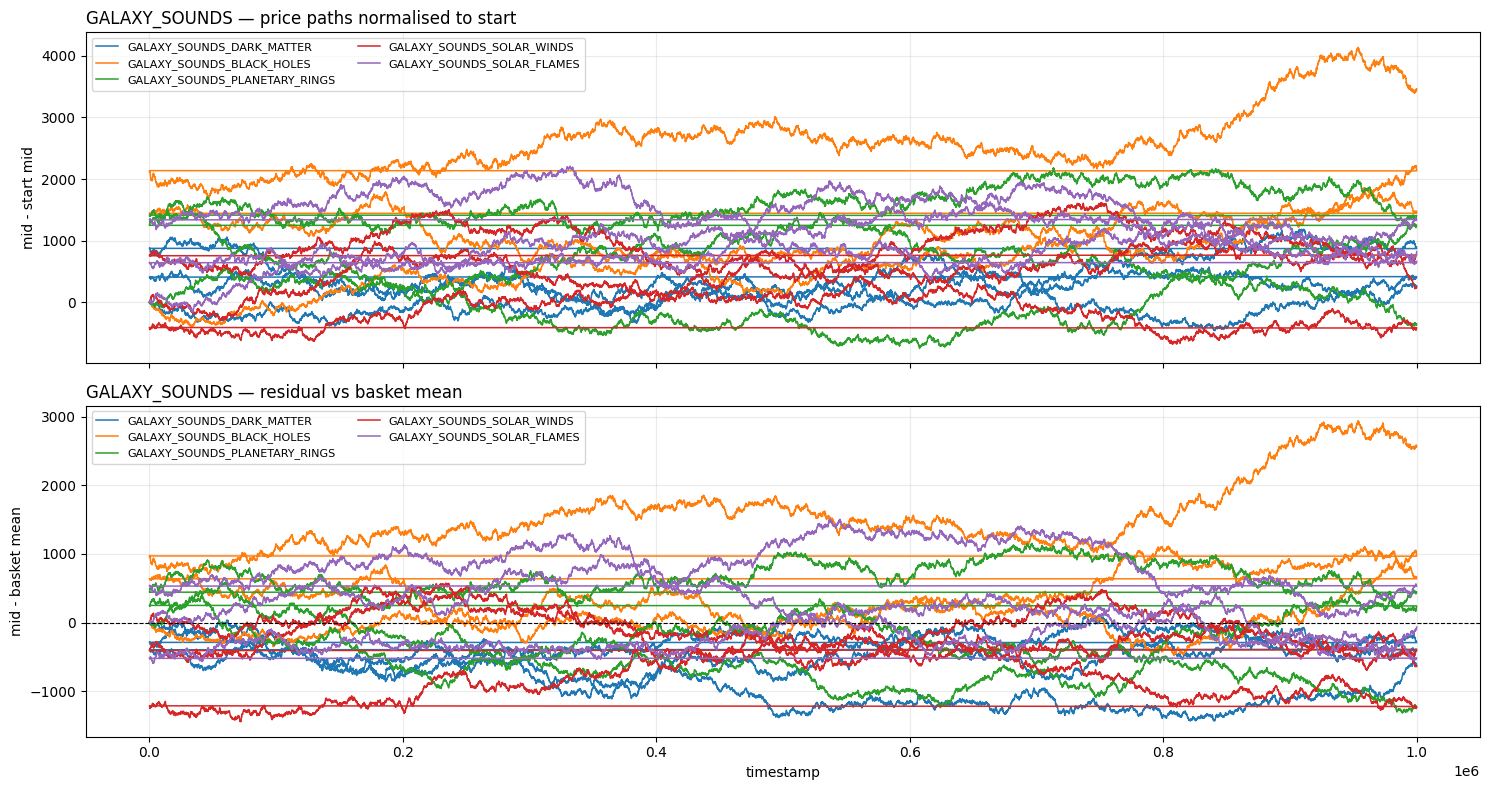

In [9]:
print("GALAXY_SOUNDS")
galaxy_sounds_summary = basket_deep_dive("GALAXY_SOUNDS")

SLEEP_POD


,product,mean_mid,mean_spread,ret_vol,ret_autocorr1,price_autocorr1,residual_abs_mean,residual_std,residual_autocorr1,last_z
0,SLEEP_POD_NYLON,9636.472567,8.564667,9.620959,0.000007,0.999821,1384.761820,521.600758,0.999854,1.482800
1,SLEEP_POD_LAMB_WOOL,10701.441717,9.400100,10.712194,0.003589,0.999664,604.379823,626.768009,0.999882,-0.347880
2,SLEEP_POD_SUEDE,11397.420433,9.949467,11.421653,-0.006330,0.999919,535.964753,509.581211,0.999803,0.154012
3,SLEEP_POD_COTTON,11527.613967,10.050200,11.676242,-0.003242,0.999913,532.157253,435.764619,0.999718,-1.005616
4,SLEEP_POD_POLYESTER,11840.560950,10.295700,11.890922,-0.001717,0.999926,858.508863,488.020283,0.999770,-0.400924


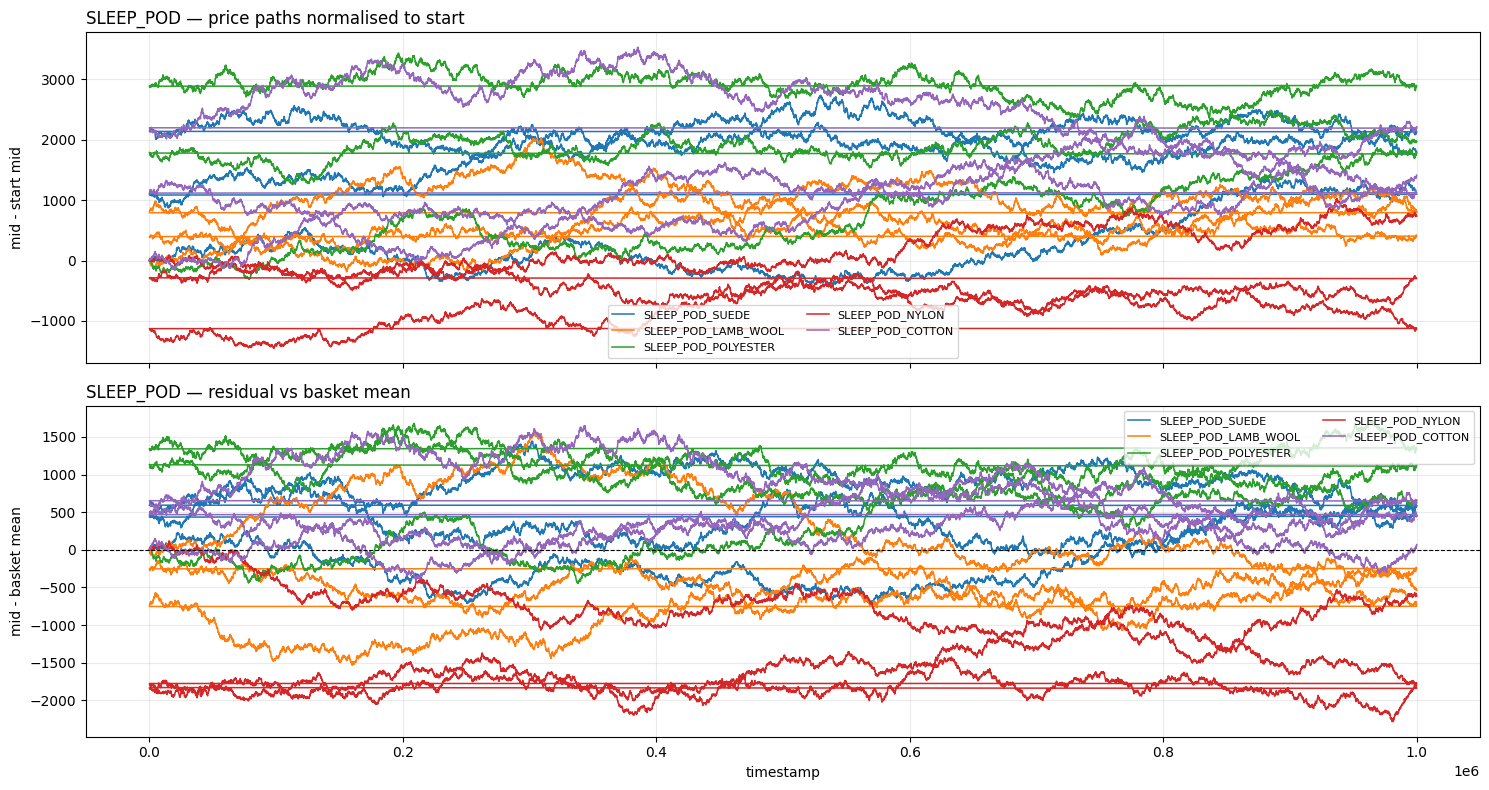

In [10]:
print("SLEEP_POD")
sleep_pod_summary = basket_deep_dive("SLEEP_POD")

MICROCHIP


,product,mean_mid,mean_spread,ret_vol,ret_autocorr1,price_autocorr1,residual_abs_mean,residual_std,residual_autocorr1,last_z
0,MICROCHIP_OVAL,8179.598717,7.449767,12.477798,-0.007204,0.999968,1708.805597,1322.515015,0.999961,-1.534793
1,MICROCHIP_RECTANGLE,8732.439350,7.885767,13.130087,-0.002692,0.999848,1176.690057,709.721353,0.999856,0.944558
2,MICROCHIP_CIRCLE,9214.885283,8.262167,9.234282,-0.004963,0.999850,915.340023,719.325449,0.999911,2.508499
3,MICROCHIP_TRIANGLE,9686.391083,8.635433,14.503819,-0.006855,0.999849,490.118597,593.252426,0.999762,-1.877917
4,MICROCHIP_SQUARE,13594.748300,11.718800,20.707015,-0.023835,0.999936,3713.482993,1930.951520,0.999960,0.346495


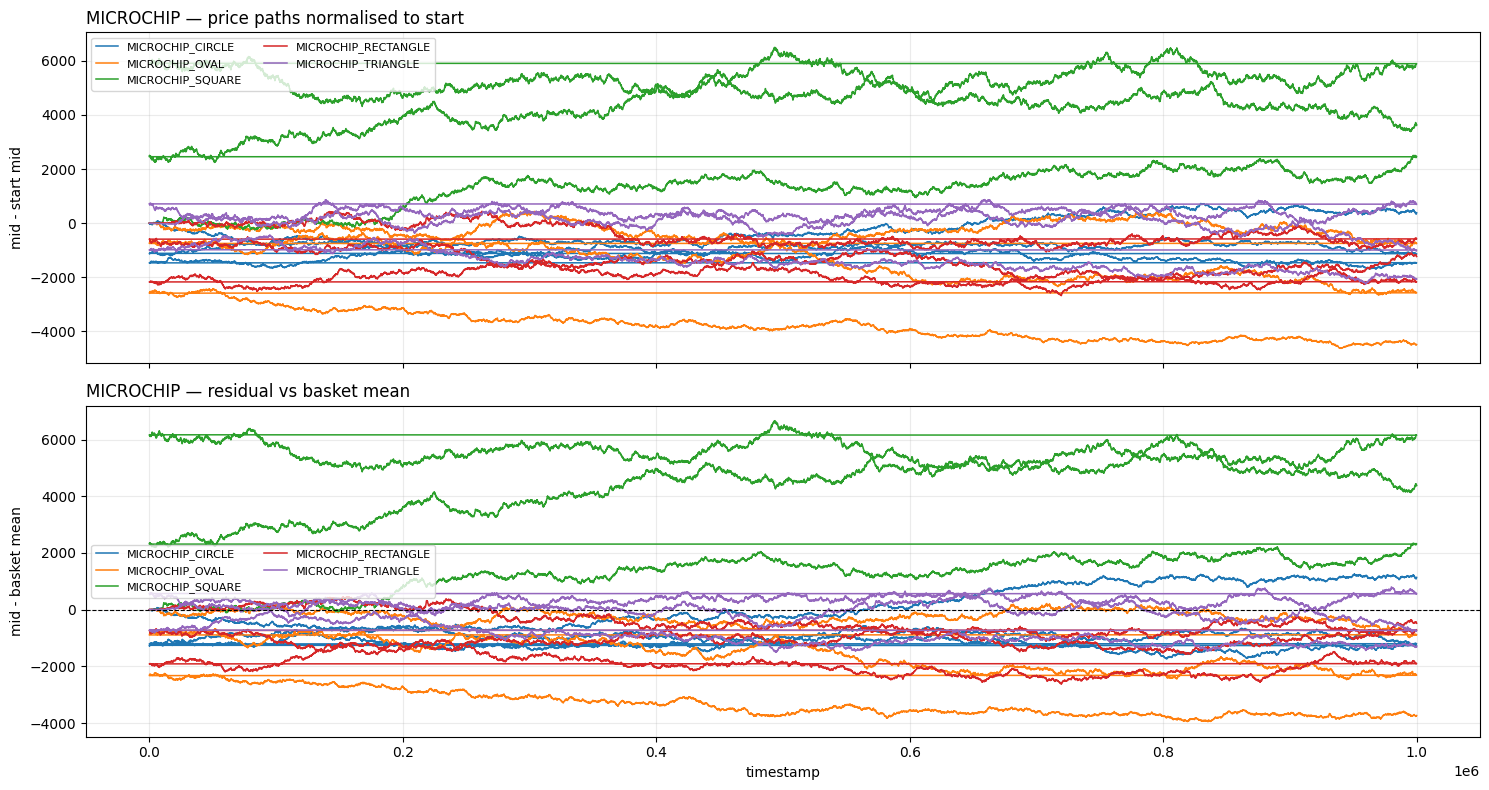

In [11]:
print("MICROCHIP")
microchip_summary = basket_deep_dive("MICROCHIP")

PEBBLES


,product,mean_mid,mean_spread,ret_vol,ret_autocorr1,price_autocorr1,residual_abs_mean,residual_std,residual_autocorr1,last_z
0,PEBBLES_XS,7404.639767,9.744867,15.052188,-0.015544,0.999946,2608.587383,1449.548468,0.999946,-0.942881
1,PEBBLES_S,8932.356733,11.551533,15.020455,0.007715,0.999838,1110.325583,833.284702,0.999838,-1.039223
2,PEBBLES_L,10174.110583,13.020500,15.026004,0.006971,0.999709,527.118987,622.330135,0.999709,-1.684351
3,PEBBLES_M,10263.243183,13.120900,15.133158,-0.004764,0.999758,620.489113,687.815908,0.999759,0.637736
4,PEBBLES_XL,13225.589317,16.630767,30.314637,0.007842,0.999854,3260.878947,1776.543992,0.999855,1.599903


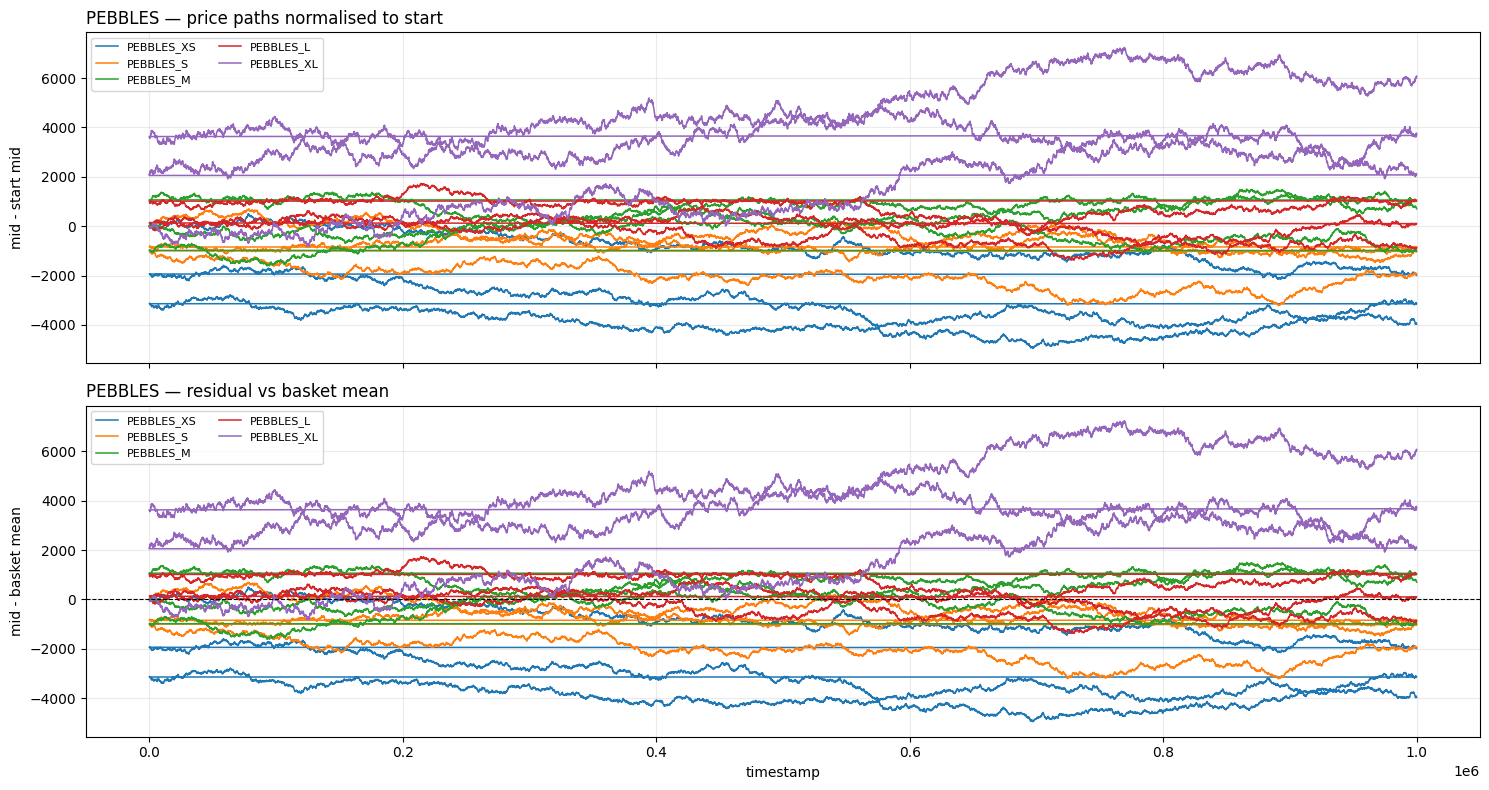

In [12]:
print("PEBBLES")
pebbles_summary = basket_deep_dive("PEBBLES")

ROBOT


,product,mean_mid,mean_spread,ret_vol,ret_autocorr1,price_autocorr1,residual_abs_mean,residual_std,residual_autocorr1,last_z
0,ROBOT_IRONING,8701.570267,6.392933,10.443533,-0.125287,0.999908,1072.610263,646.418878,0.999887,-1.143288
1,ROBOT_VACUUMING,9166.775783,6.753300,9.235882,-0.007952,0.999851,618.837720,419.392773,0.999773,-1.810352
2,ROBOT_LAUNDRY,9822.761700,7.165067,9.822607,0.005681,0.999872,433.810083,492.691901,0.999819,-0.884396
3,ROBOT_DISHES,10018.314900,7.350267,17.779323,-0.231750,0.999490,547.247930,655.030698,0.999745,2.006337
4,ROBOT_MOPPING,11100.213233,7.970667,11.145534,-0.011019,0.999894,1344.385630,872.174240,0.999931,0.710654


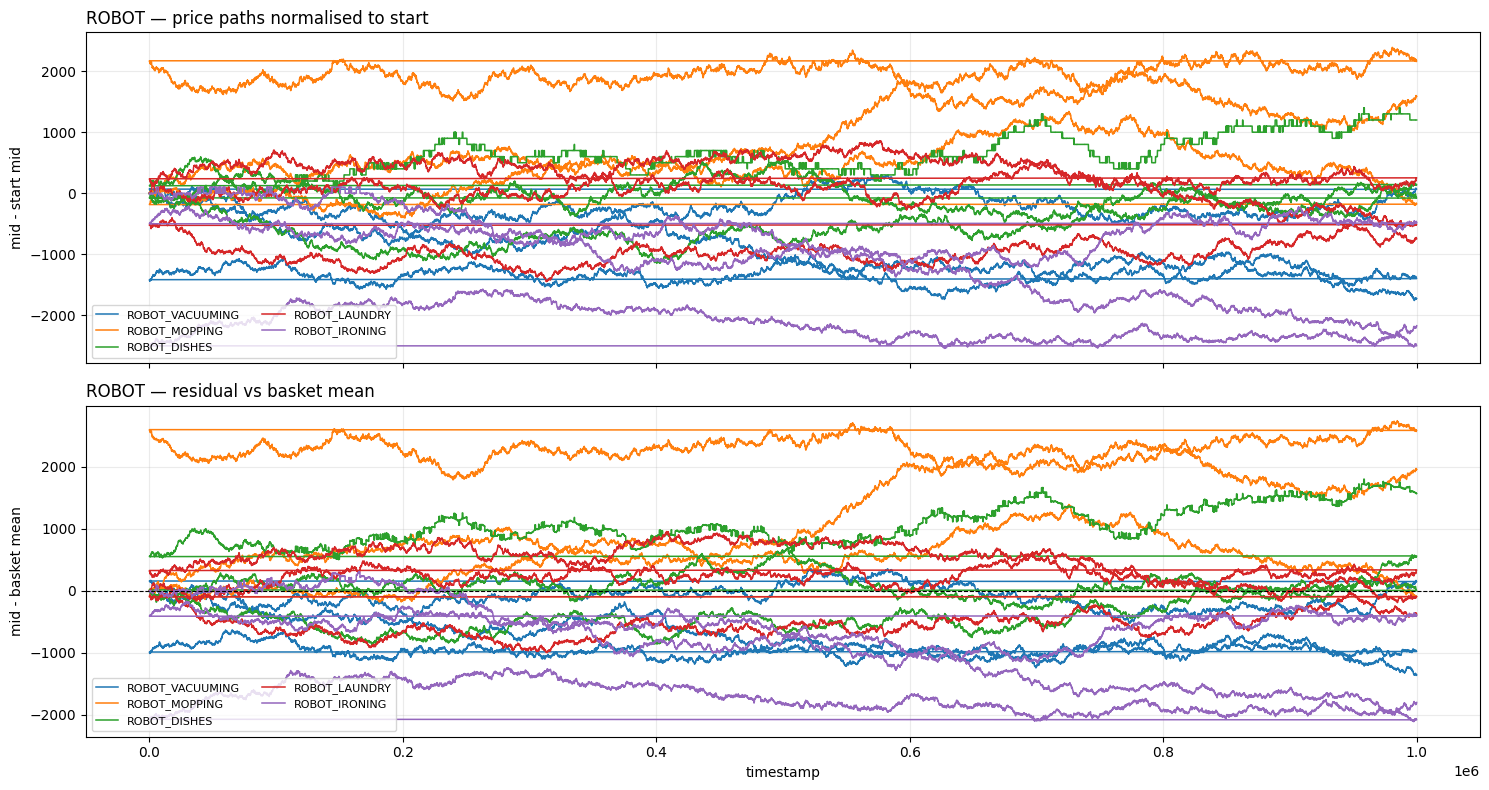

In [13]:
print("ROBOT")
robot_summary = basket_deep_dive("ROBOT")

UV_VISOR


,product,mean_mid,mean_spread,ret_vol,ret_autocorr1,price_autocorr1,residual_abs_mean,residual_std,residual_autocorr1,last_z
0,UV_VISOR_AMBER,7911.696250,10.320500,8.004815,-0.004189,0.999968,2382.487123,1075.578861,0.999974,-0.415261
1,UV_VISOR_ORANGE,10426.506217,13.284100,10.460569,0.001620,0.999820,405.056343,479.360934,0.999812,-1.566578
2,UV_VISOR_YELLOW,10957.460750,13.909967,11.006193,0.002731,0.999870,757.120403,599.395447,0.999869,-0.919945
3,UV_VISOR_RED,11063.293583,14.039433,11.030223,-0.003056,0.999824,782.368990,582.399775,0.999862,1.707172
4,UV_VISOR_MAGENTA,11111.792900,14.091600,11.203338,-0.003019,0.999833,858.880960,537.024877,0.999833,1.405441


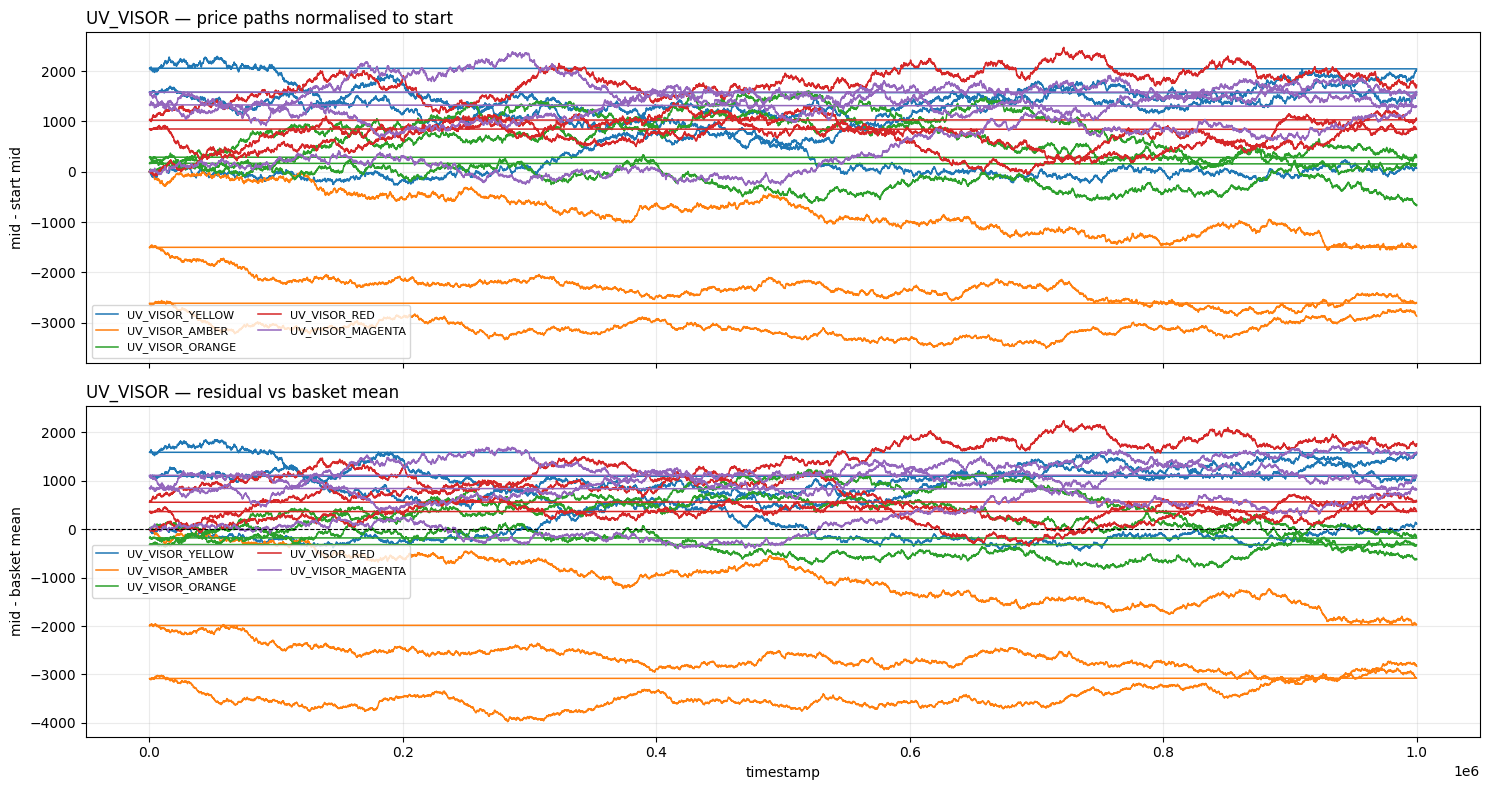

In [14]:
print("UV_VISOR")
uv_visor_summary = basket_deep_dive("UV_VISOR")

TRANSLATOR


,product,mean_mid,mean_spread,ret_vol,ret_autocorr1,price_autocorr1,residual_abs_mean,residual_std,residual_autocorr1,last_z
0,TRANSLATOR_ASTRO_BLACK,9385.219167,8.366400,9.448996,-0.006243,0.999814,624.588217,508.122211,0.999858,-0.396760
1,TRANSLATOR_SPACE_GRAY,9431.901883,8.402167,9.423637,0.007716,0.999824,533.760340,474.185549,0.999838,-1.650800
2,TRANSLATOR_ECLIPSE_CHARCOAL,9813.741883,8.700433,9.857095,-0.007415,0.999616,253.961607,302.046117,0.999573,0.433293
3,TRANSLATOR_GRAPHITE_MIST,10084.639683,8.912100,10.129680,-0.003675,0.999794,338.716527,428.473519,0.999780,-0.168093
4,TRANSLATOR_VOID_BLUE,10858.579333,9.524667,10.833879,-0.008393,0.999825,948.597390,559.334659,0.999857,1.654711


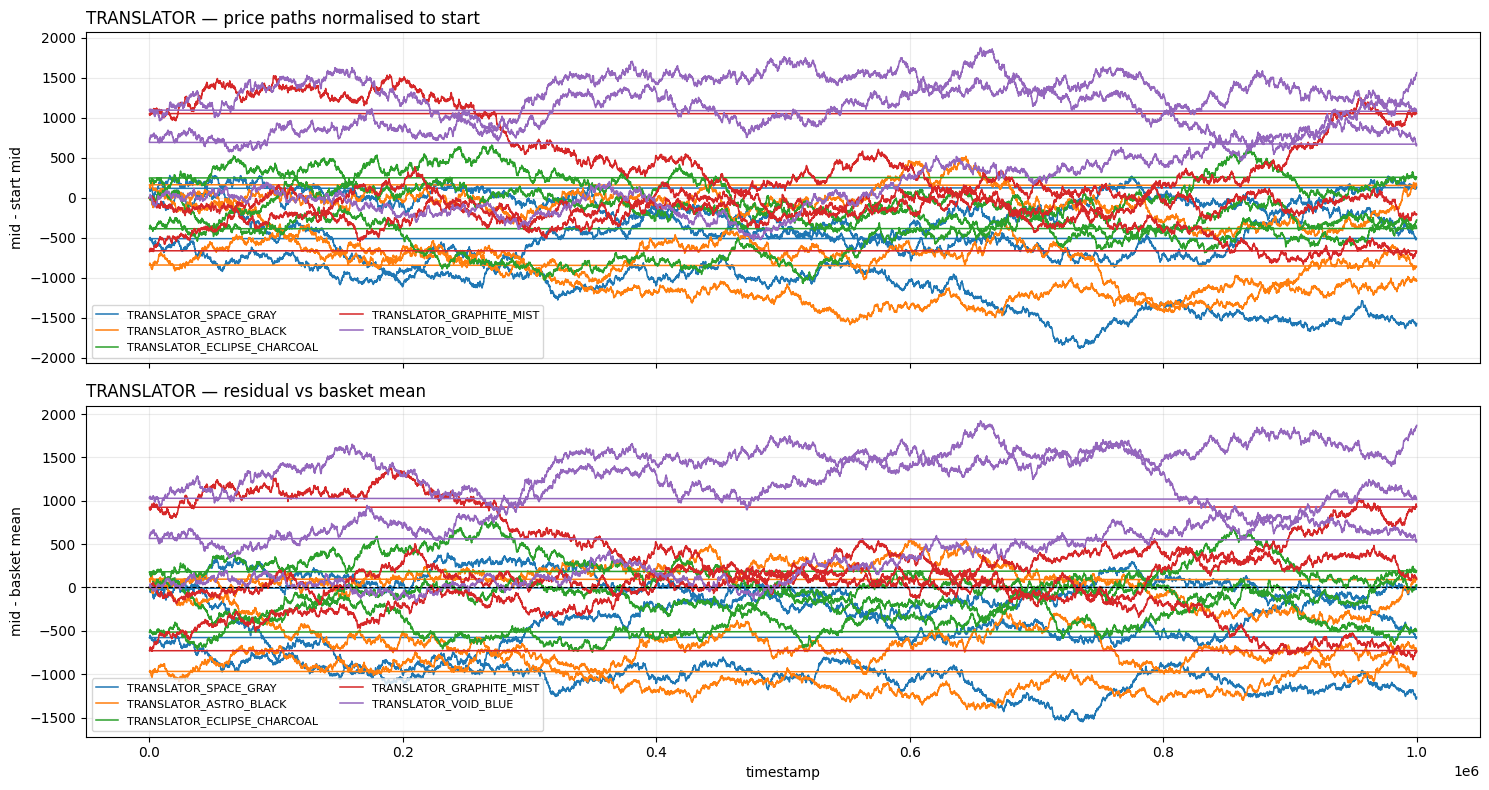

In [15]:
print("TRANSLATOR")
translator_summary = basket_deep_dive("TRANSLATOR")

PANEL


,product,mean_mid,mean_spread,ret_vol,ret_autocorr1,price_autocorr1,residual_abs_mean,residual_std,residual_autocorr1,last_z
0,PANEL_1X2,8922.729017,11.509767,9.054059,-0.002367,0.999882,886.680133,578.521565,0.999898,1.074759
1,PANEL_1X4,9397.580617,8.376633,9.484077,-0.001656,0.999935,694.434173,723.212379,0.999930,-0.444656
2,PANEL_2X2,9576.598433,8.515467,9.596827,-0.011190,0.999899,565.447783,620.639862,0.999903,-0.539924
3,PANEL_4X4,9878.719267,8.750467,9.956789,-0.005666,0.999763,367.027790,489.650674,0.999836,-1.841556
4,PANEL_2X4,11265.372983,9.840500,11.289205,0.000055,0.999838,1457.174673,688.414222,0.999899,1.360557


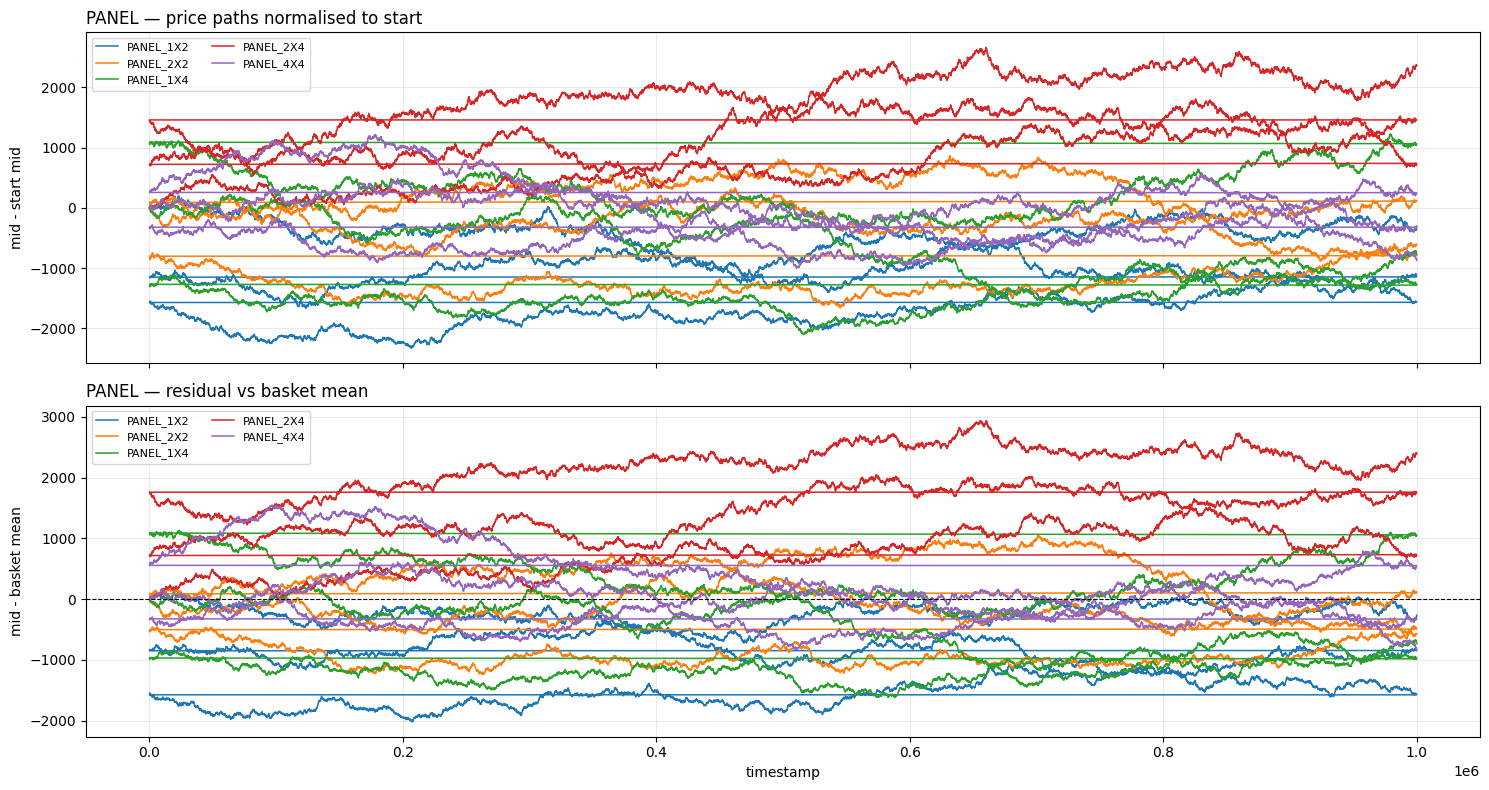

In [16]:
print("PANEL")
panel_summary = basket_deep_dive("PANEL")

OXYGEN_SHAKE


,product,mean_mid,mean_spread,ret_vol,ret_autocorr1,price_autocorr1,residual_abs_mean,residual_std,residual_autocorr1,last_z
0,OXYGEN_SHAKE_EVENING_BREATH,9271.895000,11.860467,10.982947,-0.122689,0.999623,856.017427,460.132736,0.999776,-1.039576
1,OXYGEN_SHAKE_CHOCOLATE,9556.879133,12.185467,10.890338,-0.089068,0.999811,618.565953,407.587400,0.999717,1.301986
2,OXYGEN_SHAKE_MINT,9838.394083,12.593567,9.883248,-0.003122,0.999811,441.146757,533.868701,0.999857,-0.580371
3,OXYGEN_SHAKE_MORNING_BREATH,10000.453350,12.782900,10.100491,-0.005219,0.999880,613.837683,702.776695,0.999915,-1.531640
4,OXYGEN_SHAKE_GARLIC,11925.639767,15.054600,12.014269,-0.003494,0.999921,1822.134727,822.177081,0.999919,1.622415


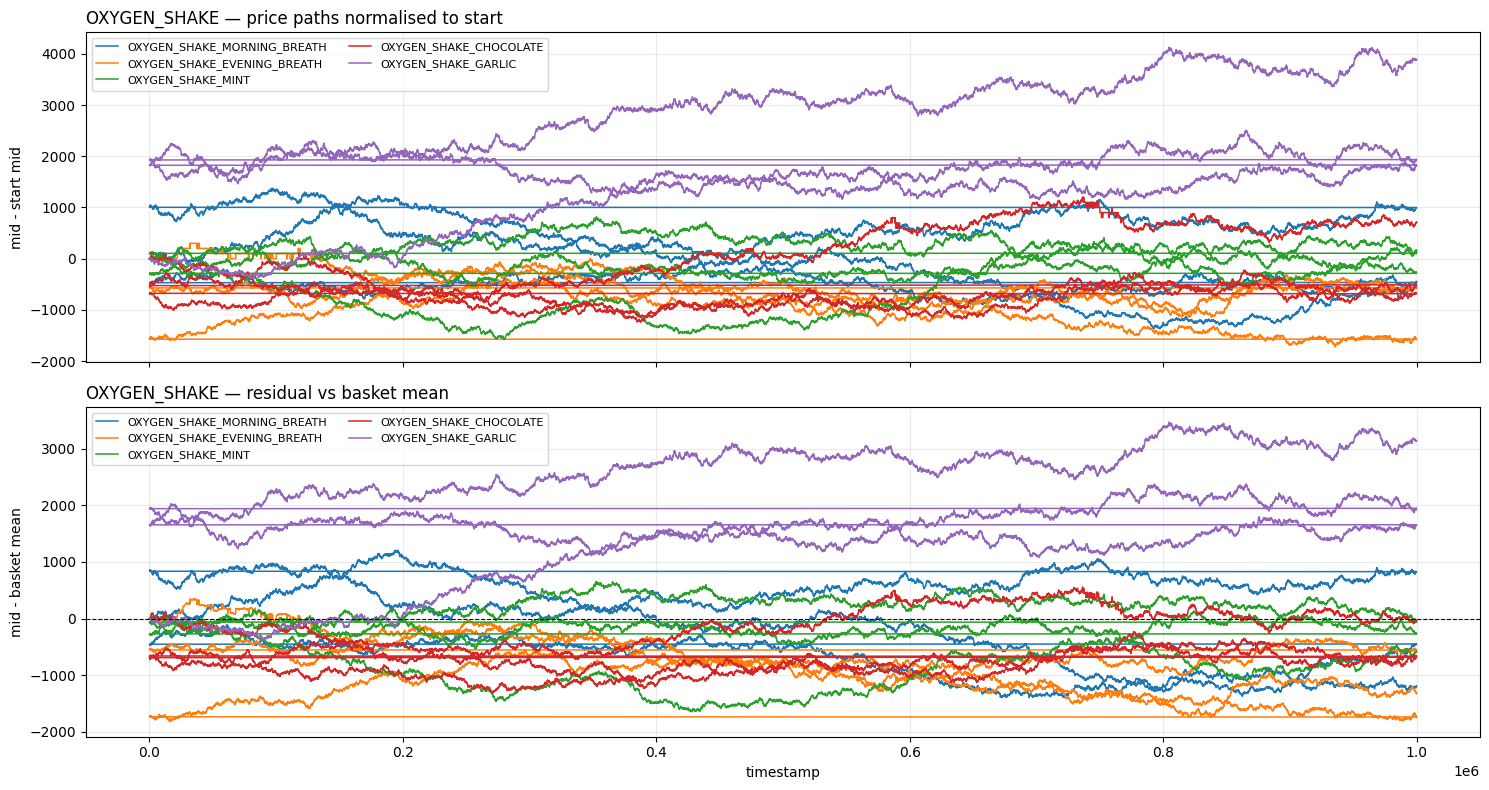

In [17]:
print("OXYGEN_SHAKE")
oxygen_shake_summary = basket_deep_dive("OXYGEN_SHAKE")

SNACKPACK


,product,mean_mid,mean_spread,ret_vol,ret_autocorr1,price_autocorr1,residual_abs_mean,residual_std,residual_autocorr1,last_z
0,SNACKPACK_PISTACHIO,9495.843917,15.925633,5.237866,-0.025157,0.999610,549.149650,194.951243,0.999780,-2.046954
1,SNACKPACK_CHOCOLATE,9843.371650,16.471167,6.575484,-0.031080,0.999463,235.592230,216.722375,0.999543,-0.911691
2,SNACKPACK_RASPBERRY,10077.812067,16.842467,8.091750,-0.016882,0.998865,158.291853,185.456152,0.998846,1.113339
3,SNACKPACK_VANILLA,10097.302467,16.868667,6.512942,-0.026951,0.999334,150.022460,174.281119,0.999304,1.213472
4,SNACKPACK_STRAWBERRY,10706.608500,17.826467,8.132929,-0.014137,0.999750,674.093753,333.777381,0.999775,0.535325


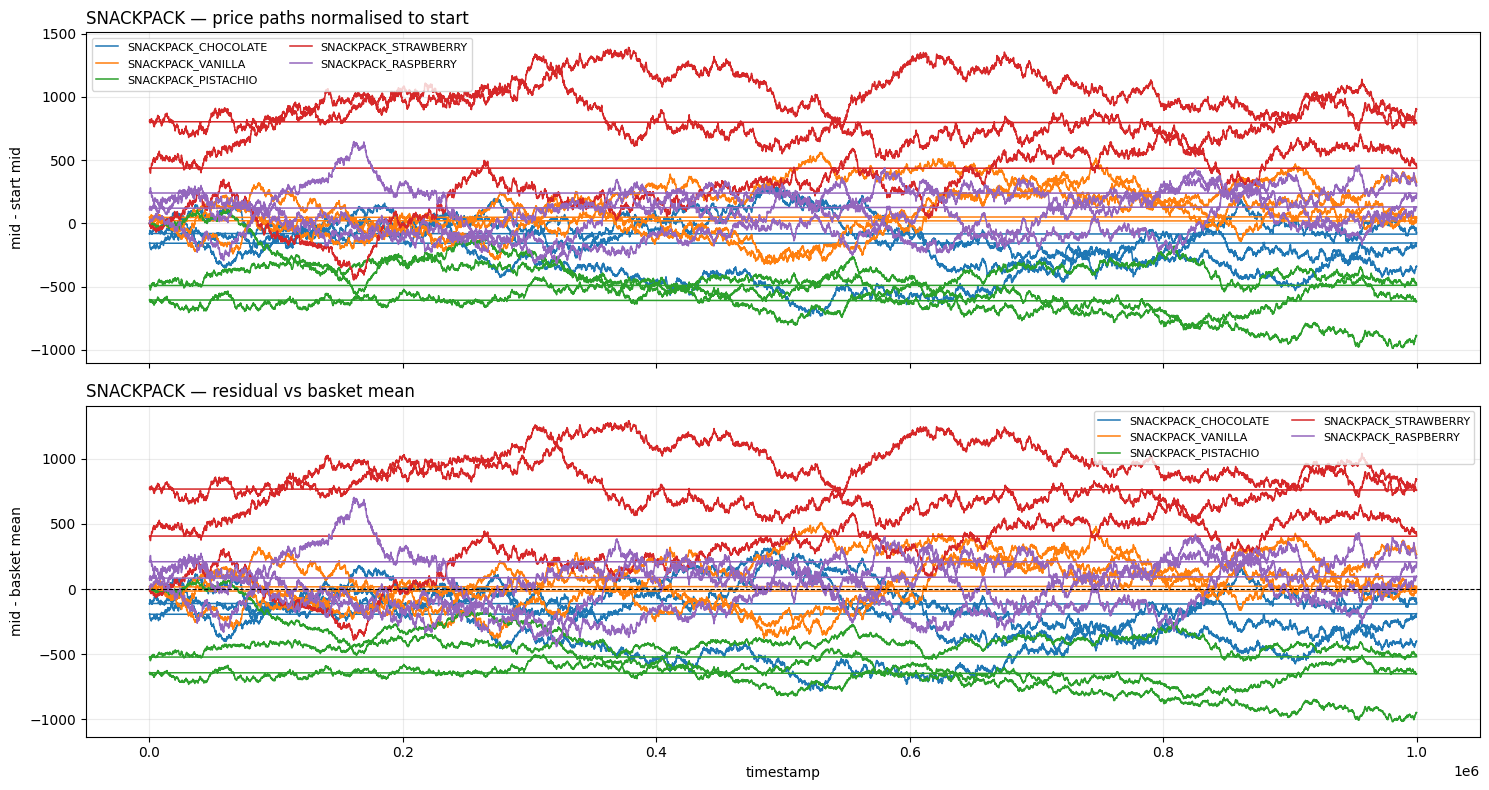

In [18]:
print("SNACKPACK")
snackpack_summary = basket_deep_dive("SNACKPACK")

## 6 — Price statistics, stationarity, and EMA tracking quality

This section keeps the useful generic diagnostics:
- raw price statistics,
- short EMA behaviour,
- trend vs reversion,
- and a basic check for whether a product is better treated as a fading name or a following name.

In [19]:
price_stats_rows = []
for p in all_products:
    df = mkt[p]
    price_stats_rows.append({
        "product": p,
        "basket": next(b for b, plist in BASKETS.items() if p in plist),
        "mean_mid": float(df["mid_price"].mean()),
        "std_mid": float(df["mid_price"].std()),
        "range_mid": float(df["mid_price"].max() - df["mid_price"].min()),
        "mean_spread": float(df["spread"].mean()),
        "median_spread": float(df["spread"].median()),
        "mean_depth": float(df["top_depth"].mean()),
        "ret_vol": float(df["mid_ret_1"].std()),
        "ret_autocorr1": autocorr(df["mid_ret_1"], 1),
        "price_autocorr1": autocorr(df["mid_price"], 1),
        "trend_10_40_mean": float(df["trend_10_40"].mean()),
        "trend_10_40_std": float(df["trend_10_40"].std()),
    })

price_stats_df = pd.DataFrame(price_stats_rows)
display(price_stats_df.sort_values("mean_mid").reset_index(drop=True))

,product,basket,mean_mid,std_mid,range_mid,mean_spread,median_spread,mean_depth,ret_vol,ret_autocorr1,price_autocorr1,trend_10_40_mean,trend_10_40_std
0,PEBBLES_XS,PEBBLES,7404.639767,1449.546839,5443.5,9.744867,9.0,26.795333,15.052188,-0.015544,0.999946,-1.932792,30.837645
1,UV_VISOR_AMBER,UV_VISOR,7911.696250,996.917584,3547.0,10.320500,10.0,36.539600,8.004815,-0.004189,0.999968,-1.400519,17.230859
2,MICROCHIP_OVAL,MICROCHIP,8179.598717,1551.911621,5058.0,7.449767,8.0,15.544067,12.477798,-0.007204,0.999968,-2.231591,25.524490
3,ROBOT_IRONING,ROBOT,8701.570267,771.029728,2643.5,6.392933,6.0,16.702933,10.443533,-0.125287,0.999908,-1.108527,18.806117
4,MICROCHIP_RECTANGLE,MICROCHIP,8732.439350,752.019290,3115.0,7.885767,8.0,14.444267,13.130087,-0.002692,0.999848,-0.588684,27.489099
5,PANEL_1X2,PANEL,8922.729017,589.916608,2536.0,11.509767,12.0,36.512800,9.054059,-0.002367,0.999882,-0.180968,19.315989
6,PEBBLES_S,PEBBLES,8932.356733,833.282141,3902.5,11.551533,12.0,24.813633,15.020455,0.007715,0.999838,-0.973029,32.110399
7,ROBOT_VACUUMING,ROBOT,9166.775783,535.258653,2060.5,6.753300,7.0,17.145467,9.235882,-0.007952,0.999851,-0.854572,19.370552
8,MICROCHIP_CIRCLE,MICROCHIP,9214.885283,532.512209,2428.0,8.262167,8.0,13.522233,9.234282,-0.004963,0.999850,0.210023,19.480914
9,OXYGEN_SHAKE_EVENING_BREATH,OXYGEN_SHAKE,9271.895000,399.821495,2022.5,11.860467,12.0,36.512800,10.982947,-0.122689,0.999623,-0.271628,19.307545


## 7 — PnL timeline, attribution, drawdown, and recovery

The `profit_and_loss` column may be strategy-specific, but it is still useful as a comparative signal.

For round 5, the practical interpretation is:
- track which products have the smoothest cumulative profile,
- look at drawdown shape,
- and compare basket stability against any built-in PnL series.

In [20]:
def drawdown_series(pnl: pd.Series) -> pd.Series:
    pnl = pd.to_numeric(pnl, errors="coerce").fillna(method="ffill").fillna(0.0)
    peak = pnl.cummax()
    return peak - pnl


pnl_rows = []
for p in all_products:
    df = mkt[p]
    if "profit_and_loss" not in df.columns or df["profit_and_loss"].dropna().empty:
        continue
    pnl = pd.to_numeric(df["profit_and_loss"], errors="coerce").fillna(method="ffill").fillna(0.0)
    dd = drawdown_series(pnl)
    pnl_rows.append({
        "product": p,
        "basket": next(b for b, plist in BASKETS.items() if p in plist),
        "final_pnl": float(pnl.iloc[-1]),
        "avg_pnl": float(pnl.mean()),
        "pnl_std": float(pnl.std()),
        "max_drawdown": float(dd.max()) if len(dd) else np.nan,
        "recovery_ratio": float(pnl.iloc[-1] / (dd.max() + 1e-9)) if len(dd) and dd.max() > 0 else np.nan,
    })

pnl_df = pd.DataFrame(pnl_rows)
display(pnl_df.sort_values("final_pnl", ascending=False).reset_index(drop=True))

,product,basket,final_pnl,avg_pnl,pnl_std,max_drawdown,recovery_ratio
0,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS,0.0,0.0,0.0,0.0,NaN
1,GALAXY_SOUNDS_DARK_MATTER,GALAXY_SOUNDS,0.0,0.0,0.0,0.0,NaN
2,GALAXY_SOUNDS_PLANETARY_RINGS,GALAXY_SOUNDS,0.0,0.0,0.0,0.0,NaN
3,GALAXY_SOUNDS_SOLAR_FLAMES,GALAXY_SOUNDS,0.0,0.0,0.0,0.0,NaN
4,GALAXY_SOUNDS_SOLAR_WINDS,GALAXY_SOUNDS,0.0,0.0,0.0,0.0,NaN
5,MICROCHIP_CIRCLE,MICROCHIP,0.0,0.0,0.0,0.0,NaN
6,MICROCHIP_OVAL,MICROCHIP,0.0,0.0,0.0,0.0,NaN
7,MICROCHIP_RECTANGLE,MICROCHIP,0.0,0.0,0.0,0.0,NaN
8,MICROCHIP_SQUARE,MICROCHIP,0.0,0.0,0.0,0.0,NaN
9,MICROCHIP_TRIANGLE,MICROCHIP,0.0,0.0,0.0,0.0,NaN


## 8 — Timestamp-synced inspection panel

Change `INSPECT_DAY` and `INSPECT_TS` to inspect a specific moment across all products.

In [21]:
INSPECT_DAY = 4
INSPECT_TS = 0

snapshot = prices_raw[(prices_raw["day"] == INSPECT_DAY) & (prices_raw["timestamp"] == INSPECT_TS)].copy()
display(snapshot.sort_values(["product"]).reset_index(drop=True))

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,spread,top_depth,book_imbalance
0,4,0,GALAXY_SOUNDS_BLACK_HOLES,12129,20,12127.0,35.0,NaN,NaN,12145,20,12146.0,35.0,NaN,NaN,12137.0,0.0,16,40,0.0
1,4,0,GALAXY_SOUNDS_DARK_MATTER,10869,20,10867.0,35.0,NaN,NaN,10883,20,10885.0,35.0,NaN,NaN,10876.0,0.0,14,40,0.0
2,4,0,GALAXY_SOUNDS_PLANETARY_RINGS,11408,20,11406.0,35.0,NaN,NaN,11423,20,11425.0,35.0,NaN,NaN,11415.5,0.0,15,40,0.0
3,4,0,GALAXY_SOUNDS_SOLAR_FLAMES,10636,20,10635.0,35.0,NaN,NaN,10650,20,10652.0,35.0,NaN,NaN,10643.0,0.0,14,40,0.0
4,4,0,GALAXY_SOUNDS_SOLAR_WINDS,10749,20,10748.0,35.0,NaN,NaN,10763,20,10765.0,35.0,NaN,NaN,10756.0,0.0,14,40,0.0
5,4,0,MICROCHIP_CIRCLE,8531,8,8530.0,8.0,NaN,NaN,8539,8,8540.0,8.0,NaN,NaN,8535.0,0.0,8,16,0.0
6,4,0,MICROCHIP_OVAL,7413,8,7412.0,8.0,NaN,NaN,7420,8,7421.0,8.0,NaN,NaN,7416.5,0.0,7,16,0.0
7,4,0,MICROCHIP_RECTANGLE,7827,8,7826.0,8.0,NaN,NaN,7834,8,7835.0,8.0,NaN,NaN,7830.5,0.0,7,16,0.0
8,4,0,MICROCHIP_SQUARE,15904,8,15903.0,8.0,NaN,NaN,15918,8,15920.0,8.0,NaN,NaN,15911.0,0.0,14,16,0.0
9,4,0,MICROCHIP_TRIANGLE,9016,8,9015.0,8.0,NaN,NaN,9024,8,9025.0,8.0,NaN,NaN,9020.0,0.0,8,16,0.0


## 9 — Trade history analysis

The trade tape is useful even if the platform does not reveal the initiating side.

This section focuses on:
- activity by product,
- average trade size,
- price concentration,
- and whether the tape is clustered at the basket level.

In [22]:
trades = trades_raw.copy().sort_values(["timestamp", "symbol"]).reset_index(drop=True)
product_to_basket = {p: b for b, plist in BASKETS.items() for p in plist}
trades["basket"] = trades["symbol"].map(product_to_basket)

trade_summary = (
    trades.groupby("symbol")
    .agg(
        basket=("basket", "first"),
        trade_count=("symbol", "size"),
        avg_price=("price", "mean"),
        std_price=("price", "std"),
        avg_qty=("quantity", "mean"),
        total_qty=("quantity", "sum"),
        first_ts=("timestamp", "min"),
        last_ts=("timestamp", "max"),
    )
    .sort_values("trade_count", ascending=False)
    .reset_index()
)
display(trade_summary)

trade_basket_summary = (
    trades.groupby("basket")
    .agg(
        trade_count=("basket", "size"),
        total_qty=("quantity", "sum"),
        avg_price=("price", "mean"),
        avg_qty=("quantity", "mean"),
    )
    .sort_values("trade_count", ascending=False)
    .reset_index()
)
display(trade_basket_summary)

,symbol,basket,trade_count,avg_price,std_price,avg_qty,total_qty,first_ts,last_ts
0,GALAXY_SOUNDS_BLACK_HOLES,GALAXY_SOUNDS,733,11485.236016,955.808996,2.462483,1805,900,999500
1,GALAXY_SOUNDS_DARK_MATTER,GALAXY_SOUNDS,733,10237.682128,343.148168,2.462483,1805,900,999500
2,GALAXY_SOUNDS_PLANETARY_RINGS,GALAXY_SOUNDS,733,10803.571623,771.174021,2.462483,1805,900,999500
3,GALAXY_SOUNDS_SOLAR_FLAMES,GALAXY_SOUNDS,733,11077.381992,428.326705,2.462483,1805,900,999500
4,GALAXY_SOUNDS_SOLAR_WINDS,GALAXY_SOUNDS,733,10460.953615,534.755803,2.462483,1805,900,999500
5,OXYGEN_SHAKE_MORNING_BREATH,OXYGEN_SHAKE,733,9970.130969,656.161273,2.462483,1805,900,999500
6,OXYGEN_SHAKE_MINT,OXYGEN_SHAKE,733,9848.354707,506.405966,2.462483,1805,900,999500
7,OXYGEN_SHAKE_GARLIC,OXYGEN_SHAKE,733,11938.290587,943.306486,2.462483,1805,900,999500
8,OXYGEN_SHAKE_EVENING_BREATH,OXYGEN_SHAKE,733,9272.128240,399.126163,2.462483,1805,900,999500
9,OXYGEN_SHAKE_CHOCOLATE,OXYGEN_SHAKE,733,9547.536153,557.933059,2.462483,1805,900,999500


,basket,trade_count,total_qty,avg_price,avg_qty
0,GALAXY_SOUNDS,3665,9025,10812.965075,2.462483
1,OXYGEN_SHAKE,3665,9025,10115.288131,2.462483
2,TRANSLATOR,3665,9025,9915.182265,2.462483
3,PANEL,3665,9025,9803.355525,2.462483
4,ROBOT,3665,9025,9754.933697,2.462483
5,SLEEP_POD,3665,9025,11042.157981,2.462483
6,UV_VISOR,3665,9025,10295.023465,2.462483
7,SNACKPACK,3665,9025,10043.188267,2.462483
8,PEBBLES,3220,11415,9999.995031,3.545031
9,MICROCHIP,2845,5595,9870.270650,1.966608


## 10 — Market dynamics: volatility, momentum, and spread efficiency

This keeps the strongest generic diagnostics:
- short-horizon volatility,
- local momentum,
- spread-to-volatility efficiency,
- and a rough read on whether passive quoting should work.

In [7]:
dynamics_rows = []
for p in all_products:
    df = mkt[p].copy()
    vol = df["mid_ret_1"].rolling(30, min_periods=8).std()
    mom = df["mid_ret_1"].rolling(30, min_periods=8).mean()
    pressure = df["book_imbalance"].rolling(30, min_periods=8).mean()

    valid = pd.DataFrame({
        "vol": vol,
        "mom": mom,
        "pressure": pressure,
        "next_ret": df["mid_ret_1"].shift(-1),
    }).dropna()

    ic_pressure = valid["pressure"].corr(valid["next_ret"], method="spearman") if len(valid) > 20 else np.nan
    ic_mom = valid["mom"].corr(valid["next_ret"], method="spearman") if len(valid) > 20 else np.nan

    dynamics_rows.append({
        "product": p,
        "basket": next(b for b, plist in BASKETS.items() if p in plist),
        "mean_spread": float(df["spread"].mean()),
        "vol_30": float(vol.mean()),
        "mom_30": float(mom.mean()),
        "pressure_ic": ic_pressure,
        "momentum_ic": ic_mom,
    })

dynamics_df = pd.DataFrame(dynamics_rows)
display(dynamics_df.sort_values("pressure_ic", ascending=False).reset_index(drop=True))

,product,basket,mean_spread,vol_30,mom_30,pressure_ic,momentum_ic
0,SNACKPACK_VANILLA,SNACKPACK,16.868667,6.459176,0.011808,0.020735,-0.001060
1,OXYGEN_SHAKE_MINT,OXYGEN_SHAKE,12.593567,9.787376,0.004601,0.020560,0.007319
2,SNACKPACK_RASPBERRY,SNACKPACK,16.842467,8.028762,0.011793,0.018290,-0.010978
3,SNACKPACK_PISTACHIO,SNACKPACK,15.925633,5.198323,-0.030942,0.016799,-0.010197
4,GALAXY_SOUNDS_PLANETARY_RINGS,GALAXY_SOUNDS,13.690033,10.748589,-0.012276,0.016713,0.013822
5,OXYGEN_SHAKE_CHOCOLATE,OXYGEN_SHAKE,12.185467,10.192270,0.023107,0.015379,-0.007409
6,SNACKPACK_CHOCOLATE,SNACKPACK,16.471167,6.523797,-0.012142,0.014875,-0.003126
7,UV_VISOR_MAGENTA,UV_VISOR,14.091600,11.096044,0.051552,0.014870,-0.012075
8,SLEEP_POD_COTTON,SLEEP_POD,10.050200,11.536493,0.046060,0.014864,0.003592
9,UV_VISOR_AMBER,UV_VISOR,10.320500,7.880063,-0.093415,0.014238,0.003937


## 11 — Market pressure gauge

This is the compact replacement for the earlier OBI regression view.

The question is simple: does top-of-book imbalance have any stable relation to the next return?

In [24]:
pressure_rank = (
    dynamics_df.groupby("basket")
    .agg(
        avg_spread=("mean_spread", "mean"),
        avg_pressure_ic=("pressure_ic", "mean"),
        avg_momentum_ic=("momentum_ic", "mean"),
    )
    .sort_values("avg_pressure_ic", ascending=False)
    .reset_index()
)
display(pressure_rank)

,basket,avg_spread,avg_pressure_ic,avg_momentum_ic
0,SNACKPACK,16.786880,0.016333,-0.006946
1,OXYGEN_SHAKE,12.895400,0.012794,-0.007212
2,SLEEP_POD,9.652027,0.009894,0.001855
3,UV_VISOR,13.129120,0.009183,-0.001809
4,GALAXY_SOUNDS,13.725287,0.006392,0.002556
5,ROBOT,7.126447,0.006005,-0.010008
6,PANEL,9.398567,0.005175,0.000799
7,PEBBLES,12.813713,0.004864,-0.003289
8,MICROCHIP,8.790387,0.003588,-0.004490
9,TRANSLATOR,8.781153,0.003329,-0.002758


## 12 — Quote placement vs bot spread

This section is useful when translating the analysis into live orders:
- compare spread width,
- compare book depth,
- estimate how much edge is available passively,
- and how much needs immediate execution.

In [8]:
quote_stats = []
for p in all_products:
    df = mkt[p].copy()
    quote_stats.append({
        "product": p,
        "basket": next(b for b, plist in BASKETS.items() if p in plist),
        "mean_bid": float(df["bid_price_1"].mean()),
        "mean_ask": float(df["ask_price_1"].mean()),
        "mean_spread": float(df["spread"].mean()),
        "median_spread": float(df["spread"].median()),
        "mean_bid_depth": float(df["bid_depth_1"].mean()),
        "mean_ask_depth": float(df["ask_depth_1"].mean()),
        "mean_top_depth": float(df["top_depth"].mean()),
        "mean_imbalance": float(df["book_imbalance"].mean()),
    })

quote_df = pd.DataFrame(quote_stats)
display(quote_df.sort_values("mean_spread").reset_index(drop=True))

,product,basket,mean_bid,mean_ask,mean_spread,median_spread,mean_bid_depth,mean_ask_depth,mean_top_depth,mean_imbalance
0,ROBOT_IRONING,ROBOT,8698.373800,8704.766733,6.392933,6.0,8.352800,8.350133,16.702933,-0.000082
1,ROBOT_VACUUMING,ROBOT,9163.399133,9170.152433,6.753300,7.0,8.604267,8.541200,17.145467,0.002987
2,ROBOT_LAUNDRY,ROBOT,9819.179167,9826.344233,7.165067,7.0,8.015533,8.079600,16.095133,-0.003015
3,ROBOT_DISHES,ROBOT,10014.639767,10021.990033,7.350267,7.0,7.624333,7.609433,15.233767,0.000441
4,MICROCHIP_OVAL,MICROCHIP,8175.873833,8183.323600,7.449767,8.0,7.796033,7.748033,15.544067,0.002485
5,MICROCHIP_RECTANGLE,MICROCHIP,8728.496467,8736.382233,7.885767,8.0,7.216367,7.227900,14.444267,-0.000633
6,ROBOT_MOPPING,ROBOT,11096.227900,11104.198567,7.970667,8.0,7.061267,7.068067,14.129333,-0.001049
7,MICROCHIP_CIRCLE,MICROCHIP,9210.754200,9219.016367,8.262167,8.0,6.769867,6.752367,13.522233,0.000813
8,TRANSLATOR_ASTRO_BLACK,TRANSLATOR,9381.035967,9389.402367,8.366400,8.0,12.037900,12.059733,24.097633,-0.000521
9,PANEL_1X4,PANEL,9393.392300,9401.768933,8.376633,8.0,12.156333,12.219567,24.375900,-0.001473


## 13 — Basket-relative residual analysis

This is the most important round-5 section.

A product is interesting only if its residual relative to its basket mean is:
- large enough,
- persistent enough,
- and not just a one-off jump that disappears immediately.

In [9]:
residual_rows = []
for basket, plist in BASKETS.items():
    pivot = master_prices[master_prices["product"].isin(plist)].pivot_table(
        index=["day", "timestamp"], columns="product", values="mid_price"
    ).sort_index()
    group_mid = pivot.mean(axis=1)
    residual = pivot.sub(group_mid, axis=0)

    for p in plist:
        res = residual[p].dropna()
        if len(res) < 20:
            continue
        residual_rows.append({
            "basket": basket,
            "product": p,
            "residual_mean": float(res.mean()),
            "residual_std": float(res.std()),
            "residual_abs_mean": float(res.abs().mean()),
            "residual_autocorr1": autocorr(res, 1),
            "residual_autocorr5": autocorr(res, 5),
            "last_residual": float(res.iloc[-1]),
            "last_residual_z": float((res.iloc[-1] - res.mean()) / (res.std() + 1e-9)),
        })

residual_df = pd.DataFrame(residual_rows)
display(residual_df.sort_values("residual_abs_mean", ascending=False).reset_index(drop=True))

,basket,product,residual_mean,residual_std,residual_abs_mean,residual_autocorr1,residual_autocorr5,last_residual,last_residual_z
0,MICROCHIP,MICROCHIP_SQUARE,3713.135753,1930.951520,3713.482993,0.999960,0.999808,4382.2,0.346495
1,PEBBLES,PEBBLES_XL,3225.601400,1776.543992,3260.878947,0.999855,0.999261,6067.9,1.599903
2,PEBBLES,PEBBLES_XS,-2595.348150,1449.548468,2608.587383,0.999946,0.999733,-3962.1,-0.942881
3,UV_VISOR,UV_VISOR_AMBER,-2382.453690,1075.578861,2382.487123,0.999974,0.999868,-2829.1,-0.415261
4,OXYGEN_SHAKE,OXYGEN_SHAKE_GARLIC,1806.987500,822.177081,1822.134727,0.999919,0.999602,3140.9,1.622415
5,MICROCHIP,MICROCHIP_OVAL,-1702.013830,1322.515015,1708.805597,0.999961,0.999810,-3731.8,-1.534793
6,PANEL,PANEL_2X4,1457.172920,688.414222,1457.174673,0.999899,0.999499,2393.8,1.360557
7,SLEEP_POD,SLEEP_POD_NYLON,-1384.229360,521.600758,1384.761820,0.999854,0.999272,-610.8,1.482800
8,ROBOT,ROBOT_MOPPING,1338.286057,872.174240,1344.385630,0.999931,0.999687,1958.1,0.710654
9,MICROCHIP,MICROCHIP_RECTANGLE,-1149.173197,709.721353,1176.690057,0.999856,0.999281,-478.8,0.944558


## 14 — Simple backtest harness for basket-relative mean reversion

This is not a full simulator.

It is only a cheap research harness that checks whether a basket residual signal is at least directionally useful before turning it into code.

In [27]:
def simple_basket_backtest(df: pd.DataFrame, threshold: float = 1.0, pos_limit: int = 10) -> dict:
    # Extremely small proxy backtest:
    # - build a basket mean from all products in the basket
    # - buy products that are far below the basket mean
    # - sell products that are far above the basket mean
    # - mark to the next basket snapshot
    if df.empty:
        return {}

    pivot = df.pivot_table(index=["day", "timestamp"], columns="product", values="mid_price").sort_index()
    basket_mid = pivot.mean(axis=1)
    residual = pivot.sub(basket_mid, axis=0)

    pnl = 0.0
    pos = {c: 0 for c in pivot.columns}
    fills = 0

    for i, idx in enumerate(pivot.index):
        row = pivot.loc[idx]
        res_row = residual.loc[idx]

        for p in pivot.columns:
            r = res_row[p]
            if pd.isna(r):
                continue
            if r < -threshold and pos[p] < pos_limit:
                pos[p] += 1
                pnl -= row[p]
                fills += 1
            elif r > threshold and pos[p] > -pos_limit:
                pos[p] -= 1
                pnl += row[p]
                fills += 1

        if i < len(pivot.index) - 1:
            next_idx = pivot.index[i + 1]
            next_row = pivot.loc[next_idx]
            mtm = pnl + sum(pos[p] * next_row[p] for p in pivot.columns)
        else:
            mtm = pnl + sum(pos[p] * row[p] for p in pivot.columns)

    return {
        "final_mtm": float(mtm),
        "fills": int(fills),
        "end_net_pos": int(sum(pos.values())),
        "gross_pos": int(sum(abs(v) for v in pos.values())),
    }


backtest_rows = []
for basket, plist in BASKETS.items():
    df = master_prices[master_prices["product"].isin(plist)].copy()
    for threshold in [0.5, 1.0, 1.5, 2.0]:
        res = simple_basket_backtest(df, threshold=threshold, pos_limit=10)
        res.update({"basket": basket, "threshold": threshold})
        backtest_rows.append(res)

backtest_df = pd.DataFrame(backtest_rows)
display(backtest_df.sort_values(["basket", "threshold"]).reset_index(drop=True))

,final_mtm,fills,end_net_pos,gross_pos,basket,threshold
0,33355.5,3632,30,50,GALAXY_SOUNDS,0.5
1,33980.0,3558,30,50,GALAXY_SOUNDS,1.0
2,33983.0,3482,30,50,GALAXY_SOUNDS,1.5
3,34021.5,3414,30,50,GALAXY_SOUNDS,2.0
4,-62048.0,2714,10,50,MICROCHIP,0.5
5,-61342.0,2658,10,50,MICROCHIP,1.0
6,-60778.0,2606,10,50,MICROCHIP,1.5
7,-60907.0,2548,10,50,MICROCHIP,2.0
8,5285.5,2616,30,50,OXYGEN_SHAKE,0.5
9,5385.0,2560,30,50,OXYGEN_SHAKE,1.0


## 15 — Cross-basket ranking

This translates the diagnostics into a compact ranking:
- tighter baskets score better for mean-reversion,
- baskets with persistent residuals score better for relative value,
- and baskets with large spreads get a caution flag.

In [10]:
rank_df = (
    residual_df.groupby("basket")
    .agg(
        avg_residual_abs=("residual_abs_mean", "mean"),
        avg_residual_std=("residual_std", "mean"),
        avg_residual_autocorr=("residual_autocorr1", "mean"),
        avg_last_abs_z=("last_residual_z", lambda s: float(np.nanmean(np.abs(s)))),
    )
    .merge(
        quote_df.groupby("basket")
        .agg(avg_spread=("mean_spread", "mean"), avg_depth=("mean_top_depth", "mean"))
        .reset_index(),
        on="basket",
        how="left",
    )
    .merge(
        dynamics_df.groupby("basket")
        .agg(avg_pressure_ic=("pressure_ic", "mean"), avg_momentum_ic=("momentum_ic", "mean"))
        .reset_index(),
        on="basket",
        how="left",
    )
    .set_index("basket")
)

rank_df["score"] = (
    -rank_df["avg_residual_abs"].rank(pct=True)
    -0.5 * rank_df["avg_spread"].rank(pct=True)
    +0.25 * rank_df["avg_pressure_ic"].rank(pct=True)
)

display(rank_df.sort_values("score", ascending=False))

,avg_residual_abs,avg_residual_std,avg_residual_autocorr,avg_last_abs_z,avg_spread,avg_depth,avg_pressure_ic,avg_momentum_ic,score
basket,,,,,,,,,
TRANSLATOR,539.924816,454.432411,0.999781,0.860731,8.781153,22.931167,0.003329,-0.002758,-0.275
SNACKPACK,353.429989,221.037654,0.999450,1.164156,16.786880,58.991300,0.016333,-0.006946,-0.350
SLEEP_POD,783.154503,516.346976,0.999805,0.678246,9.652027,22.084367,0.009894,0.001855,-0.450
ROBOT,803.378325,617.141698,0.999831,1.311005,7.126447,15.861327,0.006005,-0.010008,-0.525
PANEL,794.152911,620.087740,0.999893,1.052290,9.398567,25.786107,0.005175,0.000799,-0.600
GALAXY_SOUNDS,556.905841,544.218922,0.999815,1.184956,13.725287,36.512800,0.006392,0.002556,-0.600
OXYGEN_SHAKE,870.340509,585.308523,0.999837,1.215198,12.895400,36.512800,0.012794,-0.007212,-0.825
MICROCHIP,1600.887453,1055.153153,0.999890,1.442452,8.790387,13.660247,0.003588,-0.004490,-1.000
UV_VISOR,1037.182764,654.751979,0.999870,1.202879,13.129120,36.518160,0.009183,-0.001809,-1.025


## 16 — Product ranking inside each basket

The final implementation should not treat all products equally.

This view helps identify which names are the cleanest candidates to:
- fade aggressively,
- quote passively,
- or keep mostly as inventory hedges.

In [29]:
product_rank_rows = []
for basket, plist in BASKETS.items():
    sub = residual_df[residual_df["basket"] == basket].copy()
    if sub.empty:
        continue
    sub = sub.merge(quote_df[["product", "mean_spread", "mean_top_depth"]], on="product", how="left")
    sub["candidate_score"] = (
        -sub["residual_abs_mean"].rank(pct=True)
        -0.5 * sub["mean_spread"].rank(pct=True)
        +0.25 * sub["residual_autocorr1"].rank(pct=True)
    )
    product_rank_rows.append(sub.sort_values("candidate_score", ascending=False))

product_rank_df = pd.concat(product_rank_rows, ignore_index=True)
display(product_rank_df.sort_values(["basket", "candidate_score"], ascending=[True, False]).reset_index(drop=True))

,basket,product,residual_mean,residual_std,residual_abs_mean,residual_autocorr1,residual_autocorr5,last_residual,last_residual_z,mean_spread,mean_top_depth,candidate_score
0,GALAXY_SOUNDS,GALAXY_SOUNDS_SOLAR_WINDS,-360.520583,454.592387,455.594370,0.999782,0.998915,-640.7,-0.616331,13.301267,36.512800,-0.30
1,GALAXY_SOUNDS,GALAXY_SOUNDS_SOLAR_FLAMES,294.507150,534.130262,487.950617,0.999831,0.999160,-65.2,-0.673445,14.071533,36.512800,-0.65
2,GALAXY_SOUNDS,GALAXY_SOUNDS_PLANETARY_RINGS,-31.391367,617.319585,540.215273,0.999877,0.999383,-1239.7,-1.957347,13.690033,36.512800,-0.70
3,GALAXY_SOUNDS,GALAXY_SOUNDS_DARK_MATTER,-571.402733,365.188725,571.976347,0.999676,0.998397,-623.7,-0.143206,13.050833,36.512800,-0.85
4,GALAXY_SOUNDS,GALAXY_SOUNDS_BLACK_HOLES,668.807533,749.863651,728.792600,0.999909,0.999548,2569.3,2.534451,14.512767,36.512800,-1.25
5,MICROCHIP,MICROCHIP_CIRCLE,-666.727263,719.325449,915.340023,0.999911,0.999554,1137.7,2.508499,8.262167,13.522233,-0.55
6,MICROCHIP,MICROCHIP_TRIANGLE,-195.221463,593.252426,490.118597,0.999762,0.998846,-1309.3,-1.877917,8.635433,12.875900,-0.55
7,MICROCHIP,MICROCHIP_OVAL,-1702.013830,1322.515015,1708.805597,0.999961,0.999810,-3731.8,-1.534793,7.449767,15.544067,-0.65
8,MICROCHIP,MICROCHIP_RECTANGLE,-1149.173197,709.721353,1176.690057,0.999856,0.999281,-478.8,0.944558,7.885767,14.444267,-0.70
9,MICROCHIP,MICROCHIP_SQUARE,3713.135753,1930.951520,3713.482993,0.999960,0.999808,4382.2,0.346495,11.718800,11.914767,-1.30


## 17 — Strategy translation table

This is the bridge between analysis and live code.

The production trader should be built around these buckets:
- basket mean-reversion when residuals are clean,
- quote-skew / inventory control when the basket is trendier,
- and no-trade when spread and residual noise are both poor.

In [11]:
translation_rows = []
for basket, plist in BASKETS.items():
    bq = rank_df.loc[basket]
    if bq["avg_residual_abs"] <= rank_df["avg_residual_abs"].median():
        role = "Primary mean-reversion basket"
        action = "Trade basket residuals aggressively but keep inventory capped."
    elif bq["avg_spread"] <= rank_df["avg_spread"].median():
        role = "Secondary / selective basket"
        action = "Use conservative thresholds and prefer passive execution."
    else:
        role = "Caution / low-priority basket"
        action = "Only trade clear dislocations; otherwise keep a flat book."
    translation_rows.append({
        "basket": basket,
        "role": role,
        "action": action,
        "avg_residual_abs": bq["avg_residual_abs"],
        "avg_spread": bq["avg_spread"],
        "avg_pressure_ic": bq["avg_pressure_ic"],
    })

strategy_translation = pd.DataFrame(translation_rows).sort_values("avg_residual_abs")
display(strategy_translation)

,basket,role,action,avg_residual_abs,avg_spread,avg_pressure_ic
9,SNACKPACK,Primary mean-reversion basket,Trade basket residuals aggressively but keep i...,353.429989,16.786880,0.016333
6,TRANSLATOR,Primary mean-reversion basket,Trade basket residuals aggressively but keep i...,539.924816,8.781153,0.003329
0,GALAXY_SOUNDS,Primary mean-reversion basket,Trade basket residuals aggressively but keep i...,556.905841,13.725287,0.006392
1,SLEEP_POD,Primary mean-reversion basket,Trade basket residuals aggressively but keep i...,783.154503,9.652027,0.009894
7,PANEL,Primary mean-reversion basket,Trade basket residuals aggressively but keep i...,794.152911,9.398567,0.005175
4,ROBOT,Secondary / selective basket,Use conservative thresholds and prefer passive...,803.378325,7.126447,0.006005
8,OXYGEN_SHAKE,Caution / low-priority basket,Only trade clear dislocations; otherwise keep ...,870.340509,12.895400,0.012794
5,UV_VISOR,Caution / low-priority basket,Only trade clear dislocations; otherwise keep ...,1037.182764,13.129120,0.009183
2,MICROCHIP,Secondary / selective basket,Use conservative thresholds and prefer passive...,1600.887453,8.790387,0.003588
3,PEBBLES,Caution / low-priority basket,Only trade clear dislocations; otherwise keep ...,1625.480003,12.813713,0.004864


## 18 — Improvement roadmap from all metrics combined

This final section turns the analysis into a practical next-step list for the round-5 trader.

The notebook is now structured so that you can:
- inspect a basket,
- identify the right residual signal,
- compare spread and liquidity,
- and then convert the result into a compact production `Trader`.

In [12]:
print("═══════════════════════════════════════════════════════════════════")
print("ROUND 5 ROADMAP")
print("═══════════════════════════════════════════════════════════════════")

top_baskets = rank_df.sort_values("score", ascending=False).head(5).index.tolist()
bottom_baskets = rank_df.sort_values("score", ascending=True).head(3).index.tolist()

print("\nBest baskets by the combined score:")
for b in top_baskets:
    row = rank_df.loc[b]
    print(f" - {b:14s} | residual_abs={row['avg_residual_abs']:.2f} | spread={row['avg_spread']:.2f} | pressure_ic={row['avg_pressure_ic']:+.4f}")

print("\nBaskets to treat with caution:")
for b in bottom_baskets:
    row = rank_df.loc[b]
    print(f" - {b:14s} | residual_abs={row['avg_residual_abs']:.2f} | spread={row['avg_spread']:.2f} | pressure_ic={row['avg_pressure_ic']:+.4f}")

print("\nExecution rules to carry into the trader:")
print("1. Use basket-relative fair value, not raw product price alone.")
print("2. Trade the cleanest baskets first; keep noisy baskets as secondary opportunities.")
print("3. Separate passive quoting from aggressive taking.")
print("4. Respect the position limit of 10 product-by-product.")
print("5. Keep a stateful EMA / residual baseline in traderData.")

═══════════════════════════════════════════════════════════════════
ROUND 5 ROADMAP
═══════════════════════════════════════════════════════════════════

Best baskets by the combined score:
 - TRANSLATOR     | residual_abs=539.92 | spread=8.78 | pressure_ic=+0.0033
 - SNACKPACK      | residual_abs=353.43 | spread=16.79 | pressure_ic=+0.0163
 - SLEEP_POD      | residual_abs=783.15 | spread=9.65 | pressure_ic=+0.0099
 - ROBOT          | residual_abs=803.38 | spread=7.13 | pressure_ic=+0.0060
 - PANEL          | residual_abs=794.15 | spread=9.40 | pressure_ic=+0.0052

Baskets to treat with caution:
 - PEBBLES        | residual_abs=1625.48 | spread=12.81 | pressure_ic=+0.0049
 - UV_VISOR       | residual_abs=1037.18 | spread=13.13 | pressure_ic=+0.0092
 - MICROCHIP      | residual_abs=1600.89 | spread=8.79 | pressure_ic=+0.0036

Execution rules to carry into the trader:
1. Use basket-relative fair value, not raw product price alone.
2. Trade the cleanest baskets first; keep noisy baskets as

## 